In [ ]:
import nltk
import numpy as np
import pandas as pd
import string
import matplotlib.pyplot as plt

from nltk.stem import PorterStemmer
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
df = pd.read_csv('laptop_scenarios_story_text.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (19545, 6)


,user_profile,budget_class,price_tier,story_text,upgrade_first,gain_class
0,student,low,high,My main problem with this Apple Ultrabook is s...,Storage,Low
1,student,medium,high,"For anyone curious, this Apple Ultrabook has b...",Storage,Low
2,student,high,high,I would describe my Apple Ultrabook like this:...,Storage,Low
3,office,low,high,My take on this Apple Ultrabook is that it loo...,Storage,Low
4,office,medium,high,Current machine note: I am using an Apple Ultr...,Storage,Low


In [ ]:
# Drop any rows with missing story
df = df.dropna(subset=['story_text']).reset_index(drop=True)
print(f'stories after dropping NaN: {len(df)}')


stories after dropping NaN: 19545


# Activity 2 Task 2 – Data Mining Algorithms for Grouping Laptop Stories

Text Preprocessing


1.tokenization

2.lowercasing

3.stop-word removal

4.punctuation removal

5.stemming

In [ ]:
df_sample = df.sample(30 ,random_state=42)
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

def preprocess(story_text):
    """Tokenize → lowercase → remove stop words & punctuation → stem."""
    tokens = nltk.word_tokenize(str(story_text))          # tokenization
    tokens = [w.lower() for w in tokens]             # lowercasing
    tokens = [w for w in tokens if w not in stop_words]   # stop words
    tokens = [w for w in tokens if w not in string.punctuation]  # punctuation
    tokens = [stemmer.stem(w) for w in tokens]       # stemming
    return ' '.join(tokens)

df_sample['clean_stories'] = df_sample['story_text'].apply(preprocess)
print("Shape of the DataFrame",df_sample.shape)
df_sample[['story_text', 'clean_stories']].head()

Shape of the DataFrame (30, 7)


,story_text,clean_stories
13845,"The more I use this Toshiba Notebook, the clea...",use toshiba notebook clearer becom help get wa...
16183,Session notes from today: I worked on my Lenov...,session note today work lenovo notebook gamer ...
5814,I am writing about a Dell Workstation that I u...,write dell workstat use design task machin fee...
8355,My take on this Lenovo Notebook is that it loo...,take lenovo notebook look balanc first glanc d...
12047,Today I spent another stretch of time with my ...,today spent anoth stretch time dell notebook t...


ceartion of TF-IDF features

In [ ]:
vectorizer = TfidfVectorizer(max_features=3500)
tfidf_matrix = vectorizer.fit_transform(df_sample['clean_stories'])

print(f'TF-IDF matrix shape: {tfidf_matrix.shape}')
print(f'Sample feature names: {vectorizer.get_feature_names_out()[:20]}')
display(pd.DataFrame(tfidf_matrix.toarray(), columns=vectorizer.get_feature_names_out()).head())

TF-IDF matrix shape: (30, 401)
Sample feature names: ['0ghz' '10' '1024gb' '10kg' '11' '128gb' '13' '1366x768' '14' '15'
 '1600x900' '16gb' '17' '1920x1080' '19kg' '1ghz' '2048gb' '23kg' '256gb'
 '3200x1800']


,0ghz,10,1024gb,10kg,11,128gb,13,1366x768,14,15,...,web,window,work,workabl,workflow,workload,workstat,would,write,wrong
0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.074521,...,0.0,0.000000,0.066955,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000
1,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.095469,0.0,0.071701,...,0.0,0.000000,0.064422,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000
2,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.062489,...,0.0,0.000000,0.112289,0.0,0.0,0.000000,0.130202,0.0,0.103144,0.000000
3,0.0,0.000000,0.120717,0.0,0.0,0.120717,0.0,0.000000,0.0,0.000000,...,0.0,0.000000,0.000000,0.0,0.0,0.070524,0.000000,0.0,0.000000,0.000000
4,0.0,0.122282,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,...,0.0,0.122282,0.141373,0.0,0.0,0.000000,0.000000,0.0,0.129858,0.149786


 K-Means Clustering

In [ ]:
# Fit K-Means with chosen optimal_k from the cell before

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df_sample['cluster'] = kmeans.fit_predict(tfidf_matrix.toarray())

print(df_sample['cluster'].value_counts().sort_index())

cluster
0    5
1    5
2    8
3    6
4    6
Name: count, dtype: int64


Dimensionality Reduction with PCA

In [ ]:
# Standardize the TF-IDF matrix before PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(tfidf_matrix.toarray())

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f'Explained variance ratio: {pca.explained_variance_ratio_}')
print(f'Total variance explained: {sum(pca.explained_variance_ratio_):.4f}')
print(X_pca.shape)


Explained variance ratio: [0.07518977 0.0674177 ]
Total variance explained: 0.1426
(30, 2)


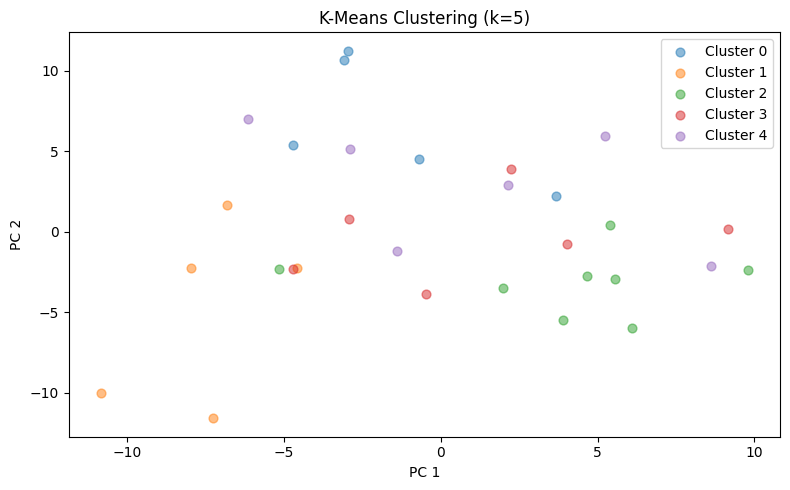

In [ ]:
# Visualize clusters
plt.figure(figsize=(8, 5))
for c in range(5):
    mask = df_sample['cluster'] == c
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], s=40, alpha=0.5, label=f'Cluster {c}')


plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.title(f'K-Means Clustering (k={5})')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
for c in range(5):

    print(f'\n--- Cluster {c} ({(df_sample["cluster"] == c).sum()} reviews) ---')

    samples = df_sample.loc[
        df_sample['cluster'] == c,
        'story_text'
    ].sample(3, random_state=42).tolist()

    for s in samples:
        print(f' • {s[:500]}...')


--- Cluster 0 (5 reviews) ---
 • Straight answer: this Lenovo Notebook is usable for a programmer, but it is not free of friction. The setup is built around an Intel Core i5 at 2.5GHz, paired with 8GB RAM, 2048GB HDD, and Intel Integrated graphics. The 8GB memory ceiling shows up quickly once my workload gets serious. The graphics side feels limited too; the Intel Integrated graphics setup does not inspire much confidence for this workload. My workflow leans on coding, compiling, debugging, documentation, and running several to...
 • I am getting increasingly annoyed with this Toshiba Notebook because it does not quite match what I need as a programmer. The setup is built around an Intel Core i5 at 2.3GHz, paired with 8GB RAM, 256GB SSD, and Intel Integrated graphics. For development work, I usually have editors, browser tabs, terminals, and background processes competing for space. The 8GB memory ceiling shows up quickly once my workload gets serious. The storage setup—256GB SSD—is w

In [ ]:
cluster_table = df_sample[['story_text', 'cluster']].copy()

cluster_table['story_text'] = cluster_table['story_text'].str[:80] + '...'

display(cluster_table.head(10))

,story_text,cluster
13845,"The more I use this Toshiba Notebook, the clea...",2
16183,Session notes from today: I worked on my Lenov...,2
5814,I am writing about a Dell Workstation that I u...,4
8355,My take on this Lenovo Notebook is that it loo...,2
12047,Today I spent another stretch of time with my ...,3
18201,"Observed in daily use, this Dell 2 in 1 Conver...",0
4755,My take on this Lenovo Notebook is that it loo...,2
12064,I am getting increasingly annoyed with this De...,1
13263,I sat down with my Dell Notebook again today a...,1
6930,I would describe my Asus Notebook like this: i...,2


# Task 4 – Graph Data Mining Concepts, Algorithms, and Tools

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import networkx as nx

In [ ]:
# Use only 10 reviews to keep the graph small
small_df = df.sample(10, random_state=42).reset_index(drop=True)

print(f"Sample size: {len(small_df)}")
print(small_df[['user_profile', 'budget_class', 'upgrade_first']].to_string())


Sample size: 10
  user_profile budget_class      upgrade_first
0      student          low  No Upgrade Needed
1        gamer       medium                RAM
2     designer          low            Storage
3      student          low  No Upgrade Needed
4      student         high  No Upgrade Needed
5   programmer          low                RAM
6      student          low            Storage
7       office       medium                RAM
8       office          low                RAM
9      student          low            Storage


In [ ]:
# Convert review text to TF-IDF

vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=200,
    min_df=2
)

tfidf_matrix = vectorizer.fit_transform(small_df["story_text"])

print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")

TF-IDF matrix shape: (10, 141)


In [ ]:
# Calculate similarity between reviews

similarity_matrix = cosine_similarity(tfidf_matrix)

# Show as a table
sim_df = pd.DataFrame(
    similarity_matrix.round(3),
    index=[f"C{i+1:02d}" for i in range(len(small_df))],
    columns=[f"C{i+1:02d}" for i in range(len(small_df))]
)
print("Cosine Similarity Matrix:")
print(sim_df)

Cosine Similarity Matrix:
       C01    C02    C03    C04    C05    C06    C07    C08    C09    C10
C01  1.000  0.227  0.292  0.303  0.258  0.337  0.600  0.137  0.286  0.403
C02  0.227  1.000  0.513  0.142  0.282  0.264  0.427  0.269  0.391  0.533
C03  0.292  0.513  1.000  0.264  0.338  0.361  0.279  0.195  0.283  0.399
C04  0.303  0.142  0.264  1.000  0.218  0.328  0.274  0.309  0.387  0.339
C05  0.258  0.282  0.338  0.218  1.000  0.329  0.182  0.225  0.202  0.320
C06  0.337  0.264  0.361  0.328  0.329  1.000  0.342  0.444  0.321  0.305
C07  0.600  0.427  0.279  0.274  0.182  0.342  1.000  0.240  0.287  0.412
C08  0.137  0.269  0.195  0.309  0.225  0.444  0.240  1.000  0.474  0.126
C09  0.286  0.391  0.283  0.387  0.202  0.321  0.287  0.474  1.000  0.229
C10  0.403  0.533  0.399  0.339  0.320  0.305  0.412  0.126  0.229  1.000


In [ ]:
# Create graph
G = nx.Graph()

# Add stories as nodes with correct attributes from your dataset
for i in range(len(small_df)):
    G.add_node(
        f"C{i+1:02d}",
        user_profile  = small_df.loc[i, 'user_profile'],
        budget_class  = small_df.loc[i, 'budget_class'],
        upgrade_first = small_df.loc[i, 'upgrade_first']
    )

Nodes : 10
Edges : 15

Top 10 edges:
  Case 01 -- Case 07  |  weight = 0.6
  Case 02 -- Case 10  |  weight = 0.533
  Case 02 -- Case 03  |  weight = 0.513
  Case 08 -- Case 09  |  weight = 0.474
  Case 06 -- Case 08  |  weight = 0.444
  Case 02 -- Case 07  |  weight = 0.427
  Case 07 -- Case 10  |  weight = 0.412
  Case 01 -- Case 10  |  weight = 0.403
  Case 03 -- Case 10  |  weight = 0.399
  Case 02 -- Case 09  |  weight = 0.391
  Case 04 -- Case 09  |  weight = 0.387
  Case 03 -- Case 06  |  weight = 0.361
  Case 06 -- Case 07  |  weight = 0.342
  Case 04 -- Case 10  |  weight = 0.339
  Case 03 -- Case 05  |  weight = 0.338


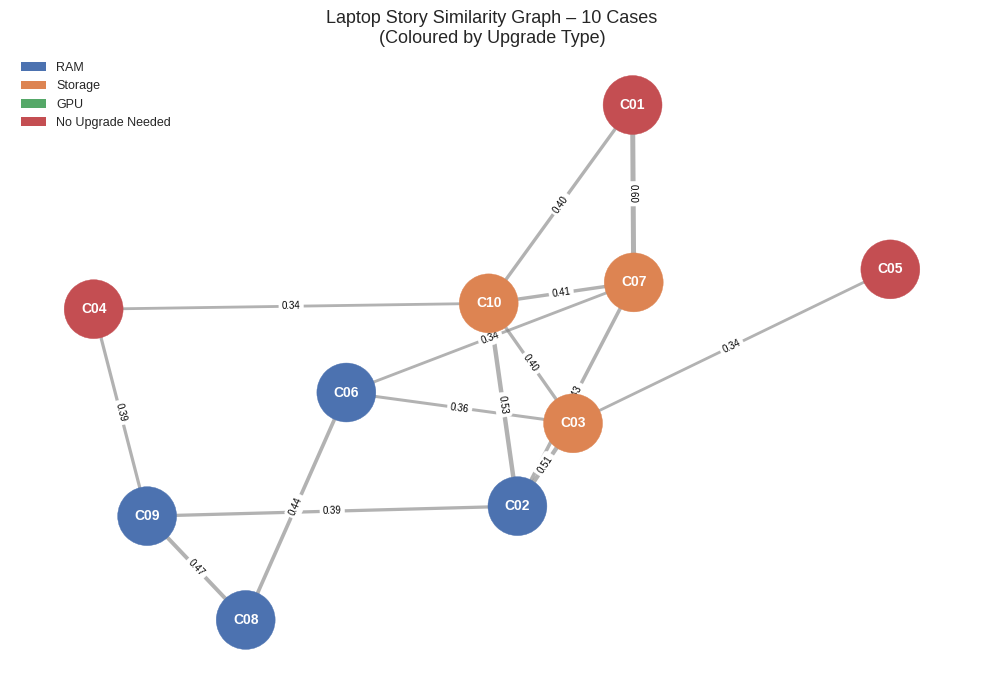

In [ ]:
# ── Reset graph ───────────────────────────────────────────────────────────────
G = nx.Graph()

# ── Add 10 nodes with attributes ─────────────────────────────────────────────
for i in range(len(small_df)):
    G.add_node(
        i,
        user_profile  = small_df.loc[i, 'user_profile'],
        budget_class  = small_df.loc[i, 'budget_class'],
        upgrade_first = small_df.loc[i, 'upgrade_first']
    )

# ── Collect all edges above threshold ────────────────────────────────────────
all_edges = []
for i in range(len(small_df)):
    for j in range(i + 1, len(small_df)):
        weight = similarity_matrix[i][j]
        if weight > 0.10:
            all_edges.append((i, j, round(weight, 3)))

# ── Keep only top 10 strongest edges ─────────────────────────────────────────
top_edges = sorted(all_edges, key=lambda x: x[2], reverse=True)[:15]

for i, j, w in top_edges:
    G.add_edge(i, j, weight=w)

print(f"Nodes : {G.number_of_nodes()}")
print(f"Edges : {G.number_of_edges()}")
print("\nTop 10 edges:")
for u, v, d in sorted(G.edges(data=True),
                       key=lambda x: x[2]['weight'], reverse=True):
    print(f"  Case {u+1:02d} -- Case {v+1:02d}  |  weight = {d['weight']}")

# ── Colour map by upgrade type ────────────────────────────────────────────────
colour_map = {
    'RAM'              : '#4C72B0',
    'Storage'          : '#DD8452',
    'GPU'              : '#55A868',
    'No Upgrade Needed': '#C44E52'
}

# ── Graph visual ──────────────────────────────────────────────────────────────
plt.figure(figsize=(10, 7))
pos = nx.spring_layout(G, seed=42, k=0.8)

# Node colours
node_colours = [
    colour_map.get(G.nodes[n]['upgrade_first'], '#999999')
    for n in G.nodes()
]

# Node labels — C01, C02 style
node_labels = {n: f"C{n+1:02d}" for n in G.nodes()}

# Edge widths by weight
edge_widths = [G[u][v]['weight'] * 6 for u, v in G.edges()]

# All edge weight labels
edge_labels = {
    (u, v): f"{d['weight']:.2f}"
    for u, v, d in G.edges(data=True)
}

# ── Draw ──────────────────────────────────────────────────────────────────────
nx.draw_networkx_nodes(G, pos, node_color=node_colours,
                       node_size=1800, alpha=1.0)
nx.draw_networkx_labels(G, pos, labels=node_labels,
                        font_size=10, font_color='white',
                        font_weight='bold')
nx.draw_networkx_edges(G, pos, width=edge_widths,
                       edge_color='gray', alpha=0.6)
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels,
                              font_size=7, font_color='black')

# ── Legend ────────────────────────────────────────────────────────────────────
from matplotlib.patches import Patch
legend = [Patch(facecolor=v, label=k) for k, v in colour_map.items()]
plt.legend(handles=legend, loc='upper left', fontsize=9, framealpha=0.9)

plt.title("Laptop Story Similarity Graph – 10 Cases\n(Coloured by Upgrade Type)",
          fontsize=13)
plt.axis('off')
plt.tight_layout()
plt.savefig('graph_visual.png', dpi=150, bbox_inches='tight')
plt.show()

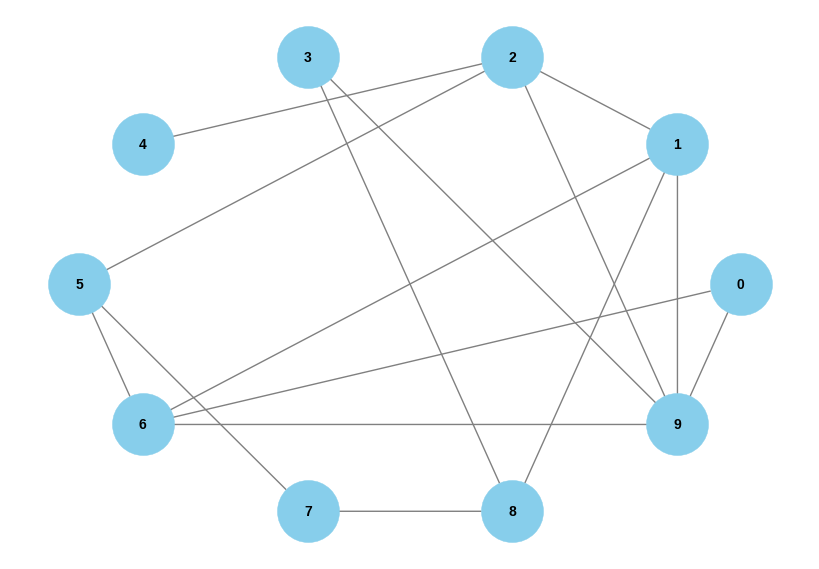

In [ ]:
pos = nx.circular_layout(G)
nx.draw(G, pos, with_labels = True, arrows=True,
        arrowsize=20,
        node_size=2000,
        node_color='skyblue',
        font_size=10, font_color='black', font_weight='bold', edge_color='gray')

plt.show(block=False)

In [ ]:
# Print only the reviews that appear in the final graph

for i in G.nodes():
    print("Review", i)
    print("upgrade_first:", small_df.loc[i, "upgrade_first"])
    print(small_df.loc[i, "story_text"][:400])
    print("-" * 80)

Review 0
upgrade_first: No Upgrade Needed
The more I use this Toshiba Notebook, the clearer it becomes where it helps me and where it gets in my way as a student. I use it for classes, browser-heavy research, documents, and the usual pile of student work. The setup is built around an Intel Core i7 at 2.6GHz, paired with 16GB RAM, 256GB SSD, and Nvidia 9xxM. To be fair, not everything is bad. The 15.6-inch 1920x1080 display with IPS panel 
--------------------------------------------------------------------------------
Review 1
upgrade_first: RAM
Session notes from today: I worked on my Lenovo Notebook as a gamer, and the machine once again showed both strengths and limits. The setup is built around an Intel Core i5 at 2.3GHz, paired with 4GB RAM, 500GB HDD, and Intel Integrated graphics. With only 4GB of RAM, the system starts to feel cramped when I multitask. I keep running into the limits of the 500GB total storage, especially with 500G
-----------------------------------------------

In [ ]:
print(G)

Graph with 10 nodes and 15 edges


In [ ]:
# ── Graph Metrics Table ───────────────────────────────────────────────────────
pagerank    = nx.pagerank(G, weight='weight')
degree      = nx.degree_centrality(G)
betweenness = nx.betweenness_centrality(G, weight='weight')
closeness   = nx.closeness_centrality(G)

metrics_df = pd.DataFrame({
    'Upgrade Type'      : small_df['upgrade_first'].values,
    'PageRank'          : [round(pagerank.get(k, 0),    4) for k in range(len(small_df))],
    'Degree Centrality' : [round(degree.get(k, 0),      4) for k in range(len(small_df))],
    'Betweenness'       : [round(betweenness.get(k, 0), 4) for k in range(len(small_df))],
    'Closeness'         : [round(closeness.get(k, 0),   4) for k in range(len(small_df))],
})


metrics_df = metrics_df.sort_values('PageRank', ascending=False).reset_index(drop=True)

metrics_df.insert(0, 'Case No',
                  ['Case ' + str(n + 1).zfill(2) for n in range(len(small_df))])
print("=" * 75)
print("                        GRAPH METRICS TABLE                            ")
print("=" * 75)
print(metrics_df.to_string(index=False))
print("=" * 75)

                        GRAPH METRICS TABLE                            
Case No      Upgrade Type  PageRank  Degree Centrality  Betweenness  Closeness
Case 01           Storage    0.1523             0.5556       0.2500     0.6429
Case 02               RAM    0.1366             0.4444       0.0833     0.6429
Case 03           Storage    0.1300             0.4444       0.1667     0.6000
Case 04           Storage    0.1289             0.4444       0.2222     0.6429
Case 05               RAM    0.1024             0.3333       0.0833     0.5294
Case 06               RAM    0.0931             0.3333       0.1944     0.5625
Case 07               RAM    0.0786             0.2222       0.0278     0.4737
Case 08 No Upgrade Needed    0.0772             0.2222       0.0000     0.4737
Case 09 No Upgrade Needed    0.0629             0.2222       0.0556     0.5000
Case 10 No Upgrade Needed    0.0380             0.1111       0.0000     0.4091



# **Activity 3 – Python Prototyping for the Smart Laptop Upgrade Advisor**





#*Clustering Notebook: Improve and Select the Best Method*

Text Preprocessing

In [ ]:
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

def preprocess(story_text):
    """Tokenize → lowercase → remove stop words & punctuation → stem."""
    tokens = nltk.word_tokenize(str(story_text))          # tokenization
    tokens = [w.lower() for w in tokens]             # lowercasing
    tokens = [w for w in tokens if w not in stop_words]   # stop words
    tokens = [w for w in tokens if w not in string.punctuation]  # punctuation
    tokens = [stemmer.stem(w) for w in tokens]       # stemming
    return ' '.join(tokens)

df['clean_stories'] = df['story_text'].apply(preprocess)
print("Shape of the DataFrame",df.shape)
df[['story_text', 'clean_stories']].head()


Shape of the DataFrame (19545, 7)


,story_text,clean_stories
0,My main problem with this Apple Ultrabook is s...,main problem appl ultrabook simpl student keep...
1,"For anyone curious, this Apple Ultrabook has b...",anyon curiou appl ultrabook machin student use...
2,I would describe my Apple Ultrabook like this:...,would describ appl ultrabook like look capabl ...
3,My take on this Apple Ultrabook is that it loo...,take appl ultrabook look balanc first glanc da...
4,Current machine note: I am using an Apple Ultr...,current machin note use appl ultrabook offic w...


TF-IDF Feature Creation

In [ ]:
vectorizer = TfidfVectorizer(max_features=3500)  # keep top 3500 terms
tfidf_matrix = vectorizer.fit_transform(df['clean_stories'])

print(f'TF-IDF matrix shape: {tfidf_matrix.shape}')
print(f'Sample feature names: {vectorizer.get_feature_names_out()[:20]}')
display(pd.DataFrame(tfidf_matrix.toarray(), columns=vectorizer.get_feature_names_out()).head())

TF-IDF matrix shape: (19545, 603)
Sample feature names: ['00kg' '02kg' '03kg' '04kg' '05kg' '06kg' '07kg' '08kg' '09kg' '0ghz'
 '10' '1024gb' '10kg' '11' '11kg' '12' '128gb' '12gb' '12kg' '13']


,00kg,02kg,03kg,04kg,05kg,06kg,07kg,08kg,09kg,0ghz,...,workabl,workflow,workload,workstat,would,write,wrong,xeon,xiaomi,yet
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.128594,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.120727,0.120629,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0


In [ ]:
X = tfidf_matrix.toarray()
from sklearn.cluster import KMeans
# Standardize the TF-IDF matrix before PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(tfidf_matrix.toarray())

pca = PCA(n_components=.65, random_state=42)
X_pca = pca.fit_transform(X_scaled)


In [ ]:


print(f'Explained variance ratio: {pca.explained_variance_ratio_}')
print(f'Total variance explained: {sum(pca.explained_variance_ratio_):.4f}')



Explained variance ratio: [0.03403813 0.02001337 0.01885224 0.01777285 0.01615614 0.0154284
 0.01462241 0.01396937 0.01394306 0.01267748 0.01245729 0.012302
 0.01219059 0.01155601 0.01104547 0.01090616 0.01071055 0.01047846
 0.01014926 0.00995167 0.00986447 0.00969424 0.00956552 0.00944166
 0.0091983  0.0090569  0.00902921 0.00885331 0.00870889 0.00851159
 0.00849844 0.00826009 0.00823047 0.00803253 0.00790708 0.00789315
 0.00781772 0.00772158 0.00762741 0.00751299 0.00737192 0.0072393
 0.00710333 0.00705683 0.00699502 0.00667475 0.00649154 0.00640629
 0.00633581 0.00622676 0.00613737 0.00606342 0.00598894 0.00594948
 0.00583691 0.00566001 0.00561386 0.00554867 0.00537349 0.00525687
 0.00515014 0.00507984 0.00486868 0.00483375 0.00479189 0.00476569
 0.00466697 0.00461906 0.00457579 0.00449138 0.00444457 0.00431308
 0.00427936 0.00417811]
Total variance explained: 0.6510


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score


#  Test K-Means With Different K Values






In [ ]:
#  Test K-Means With Different K Values before pca


for k in range(2, 8):
    kmeans_test = KMeans(
        n_clusters=k,
        init='k-means++',
        random_state=42,
        n_init=10
    )

    labels = kmeans_test.fit_predict(X)
    score = silhouette_score(X, labels)

    print(f"K={k}, Silhouette Score={score}")

K=2, Silhouette Score=0.05016241348234554
K=3, Silhouette Score=0.04119350640015181
K=4, Silhouette Score=0.0519104249188417
K=5, Silhouette Score=0.06076299580870825
K=6, Silhouette Score=0.0558375664205469
K=7, Silhouette Score=0.06654866151960773


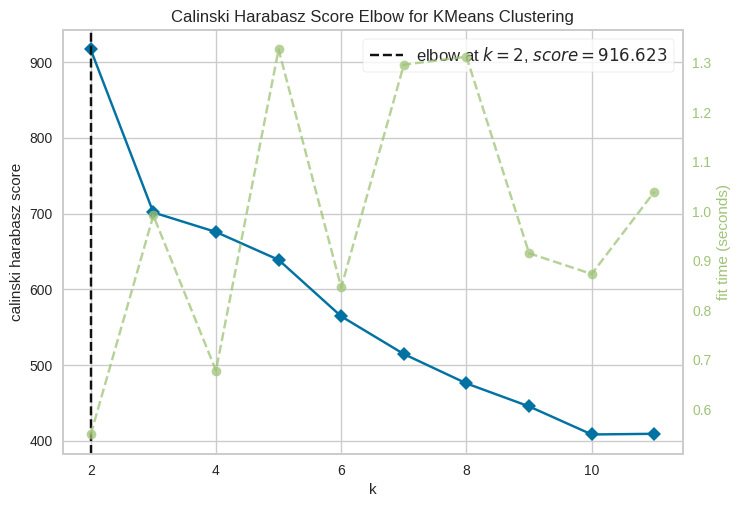

Suggested k: 2


In [ ]:
from yellowbrick.cluster import KElbowVisualizer

# Initialize the clustering model
model = KMeans(random_state=42)

# Instantiate the visualizer with a range of k from 2 to 12
visualizer = KElbowVisualizer(model, k=(2,12),metric='calinski_harabasz') #you can set the metric to distortion , silhouette , calinski_harabasz

# Fit the data to the visualizer
visualizer.fit(X)

# Render the plot
visualizer.show()

optimal_k = visualizer.elbow_value_
print("Suggested k:", optimal_k)

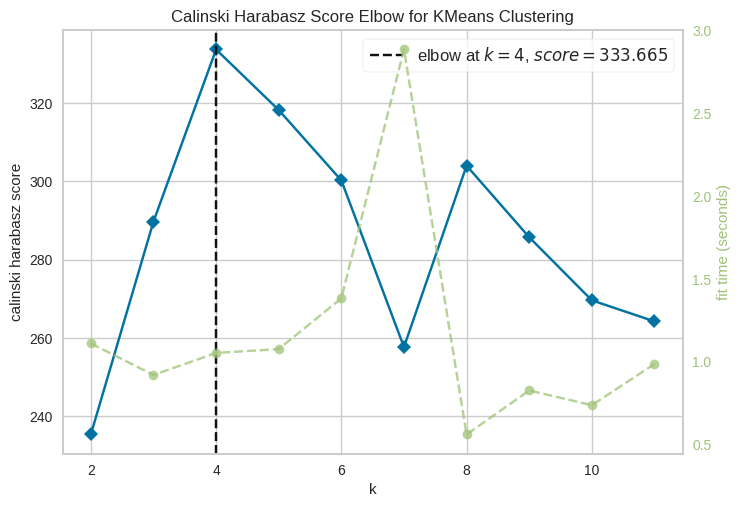

Suggested k: 4


In [ ]:
from yellowbrick.cluster import KElbowVisualizer

# Initialize the clustering model
model = KMeans(random_state=42)

# Instantiate the visualizer with a range of k from 2 to 12
visualizer = KElbowVisualizer(model, k=(2,12),metric='calinski_harabasz') #you can set the metric to distortion , silhouette , calinski_harabasz

# Fit the data to the visualizer
visualizer.fit(X_scaled)

# Render the plot
visualizer.show()

optimal_k = visualizer.elbow_value_
print("Suggested k:", optimal_k)

| Experiment    | Suggested K |
| ------------- | ----------- |
| Raw TF-IDF    | 2           |
| Scaled TF-IDF | 4           |


Additional experiments were performed using standardized TF-IDF features before clustering. However, the clustering quality became weaker after scaling, with lower silhouette scores and less interpretable cluster structures.

###KMeans - Random

KMeans - Random before PCA

In [ ]:
# Fit K-Means with 5 clusters , the dr told me to put it 5 with no need to check


kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['cluster_kmeans_before_PCA'] = kmeans.fit_predict(X)

print(df['cluster_kmeans_before_PCA'].value_counts().sort_index())

cluster_kmeans_before_PCA
0    3908
1    3909
2    3909
3    3910
4    3909
Name: count, dtype: int64


In [ ]:
from sklearn.preprocessing import LabelEncoder


In [ ]:
# ── Encode user_profile as true labels ───────────────────────────────────────
le = LabelEncoder()
true_labels = le.fit_transform(df['user_profile'])

print("User profile classes:")
for i, cls in enumerate(le.classes_):
    print(f"  {i} → {cls}")

User profile classes:
  0 → designer
  1 → gamer
  2 → office
  3 → programmer
  4 → student


In [ ]:
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    adjusted_rand_score,
    adjusted_mutual_info_score
)

In [ ]:
results = {}

In [ ]:


# KMeans — use tfidf_matrix (full features)
results['KMeans_before_PCA'] = {
    'Clusters'   : kmeans.n_clusters,
    'Silhouette' : round(silhouette_score(tfidf_matrix, df['cluster_kmeans_before_PCA']), 4),
    'CH Score'   : round(calinski_harabasz_score(tfidf_matrix.toarray(), df['cluster_kmeans_before_PCA']), 2),
    'DB Index'   : round(davies_bouldin_score(tfidf_matrix.toarray(), df['cluster_kmeans_before_PCA']), 4),
    'ARI'        : round(adjusted_rand_score(true_labels, df['cluster_kmeans_before_PCA']), 4),
    'AMI'        : round(adjusted_mutual_info_score(true_labels, df['cluster_kmeans_before_PCA']), 4),
}


In [ ]:
print(results)

{'KMeans_before_PCA': {'Clusters': 5, 'Silhouette': np.float64(0.0608), 'CH Score': np.float64(638.92), 'DB Index': np.float64(3.8345), 'ARI': 0.9999, 'AMI': np.float64(0.9997)}}


In [ ]:
from joblib import dump
import scipy.sparse

# Save everything in one dictionary
model_bundle = {
    'kmeans'      : kmeans,
    'vectorizer'  : vectorizer,
    'tfidf_matrix': tfidf_matrix,
}

dump(model_bundle, 'laptop_advisor_models.joblib')
print("✅ Saved!")

✅ Saved!


In [ ]:
# Run this in Colab to download the file
from google.colab import files
files.download('laptop_advisor_models.joblib')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Step 1 — upgrade scikit-learn to match your local version
!pip install scikit-learn==1.7.2

# Step 2 — retrain with the new version
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from joblib import dump

stemmer    = PorterStemmer()
stop_words = set(stopwords.words('english'))

def preprocess(story_text):
    tokens = nltk.word_tokenize(story_text.lower())
    tokens = [stemmer.stem(w) for w in tokens
              if w not in stop_words and w not in string.punctuation]
    return ' '.join(tokens)

df['clean_stories'] = df['story_text'].apply(preprocess)

vectorizer   = TfidfVectorizer(max_features=3500)
tfidf_matrix = vectorizer.fit_transform(df['clean_stories'])

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
kmeans.fit(tfidf_matrix)

# Step 3 — save bundle
bundle = {
    'kmeans'      : kmeans,
    'vectorizer'  : vectorizer,
    'tfidf_matrix': tfidf_matrix,
}
dump(bundle, 'laptop_advisor_models.joblib')

# Step 4 — verify cluster mapping
for i in range(5):
    mask     = kmeans.labels_ == i
    dominant = df.loc[mask, 'user_profile'].value_counts().idxmax()
    print(f"Cluster {i} → {dominant}")

# Step 5 — download
from google.colab import files
files.download('laptop_advisor_models.joblib')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 61.7 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1


Cluster 0 → gamer
Cluster 1 → programmer
Cluster 2 → student
Cluster 3 → office
Cluster 4 → designer


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

###KMeans - Random after pca



In [ ]:
kmeans_random = KMeans( n_clusters=5,
    init='random',
    random_state=42,

)
df['KMeans - Random after pca'] = kmeans_random.fit_predict(X_pca)

print(df['KMeans - Random after pca'].value_counts().sort_index())


KMeans - Random after pca
0    3316
1    6044
2    3733
3    2719
4    3733
Name: count, dtype: int64


In [ ]:


# KMeans — use tfidf_matrix (full features)
results['KMeans_after_pca'] = {
    'Clusters'   : kmeans_random.n_clusters,
    'Silhouette' : round(silhouette_score(X_pca,df['KMeans - Random after pca']), 4),
    'CH Score'   : round(calinski_harabasz_score(X_pca, df['KMeans - Random after pca']), 2),
    'DB Index'   : round(davies_bouldin_score(X_pca,df['KMeans - Random after pca']), 4),
    'ARI'        : round(adjusted_rand_score(true_labels,df['KMeans - Random after pca']), 4),
    'AMI'        : round(adjusted_mutual_info_score(true_labels, df['KMeans - Random after pca']), 4),
}

In [ ]:
results

{'KMeans_before_PCA': {'Clusters': 5,
  'Silhouette': np.float64(0.0608),
  'CH Score': np.float64(638.92),
  'DB Index': np.float64(3.8345),
  'ARI': 0.9999,
  'AMI': np.float64(0.9997)},
 'KMeans_after_pca': {'Clusters': 5,
  'Silhouette': np.float64(0.0476),
  'CH Score': np.float64(565.01),
  'DB Index': np.float64(4.2916),
  'ARI': 0.5869,
  'AMI': np.float64(0.6515)}}

without pca the silhouette score is better

kmeans with 2d pca (just for sure)

In [ ]:
pca_2d = PCA(n_components=2, random_state=42)

X_pca1 = pca_2d.fit_transform(X_scaled)

print("Explained variance ratio:", pca_2d.explained_variance_ratio_)
print("Total variance explained:", sum(pca_2d.explained_variance_ratio_))
print(X_pca1.shape)

Explained variance ratio: [0.03403813 0.02001337]
Total variance explained: 0.05405150340395183
(19545, 2)


In [ ]:
# 1. Fit KMeans ON the 2D PCA data
kmeans_2d = KMeans(n_clusters=5, random_state=42, n_init=10)
labels_2d = kmeans_2d.fit_predict(X_pca1)          # labels from 2D space

# 2. Store labels
df['cluster_kmeans_2dpca'] = labels_2d

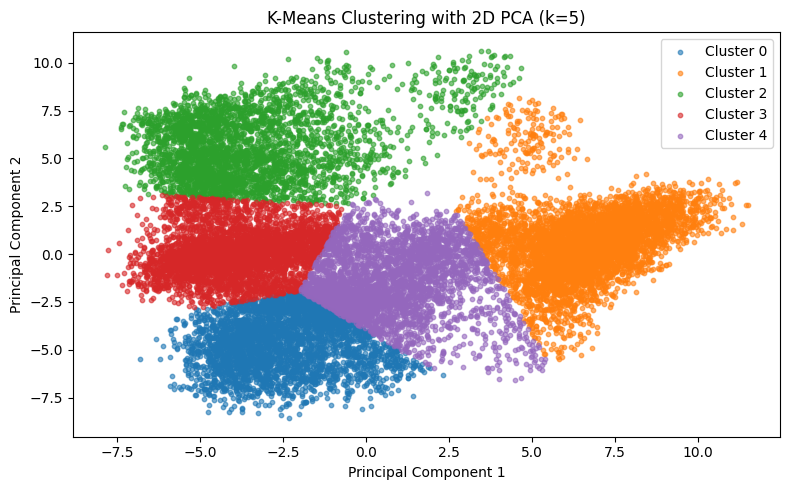

In [ ]:
# Visualize clusters using 2D PCA

plt.figure(figsize=(8, 5))

for c in range(5):

    mask =  df['cluster_kmeans_2dpca'] == c

    plt.scatter(
        X_pca1[mask, 0],
        X_pca1[mask, 1],
        s=10,
        alpha=0.6,
        label=f'Cluster {c}'
    )

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

plt.title(f'K-Means Clustering with 2D PCA (k={5})')

plt.legend()

plt.tight_layout()

plt.show()

In [ ]:
# KMeans — use tfidf_matrix (full features)
results['KMeans_after_2Dpca'] = {
    'Clusters'   : 5,
    'Silhouette' : round(silhouette_score(X_pca1, df['cluster_kmeans_2dpca']), 4),
    'CH Score'   : round(calinski_harabasz_score(X_pca1, df['cluster_kmeans_2dpca']), 2),
    'DB Index'   : round(davies_bouldin_score(X_pca1, df['cluster_kmeans_2dpca']), 4),
    'ARI'        : round(adjusted_rand_score(true_labels, df['cluster_kmeans_2dpca']), 4),
    'AMI'        : round(adjusted_mutual_info_score(true_labels, df['cluster_kmeans_2dpca']), 4),
}


In [ ]:
results

{'KMeans_after_2Dpca': {'Clusters': 5,
  'Silhouette': np.float64(0.4418),
  'CH Score': np.float64(26135.49),
  'DB Index': np.float64(0.7677),
  'ARI': 0.4742,
  'AMI': np.float64(0.5317)}}

PCA was applied to visualize the clusters in two dimensions. However, the first two principal components explained only 5.4% of the total variance. Therefore, PCA was used mainly for visualization, while the final clustering results were obtained using the original TF-IDF feature space.

# Agglomerative Clustering

Agglomerative model before pca



In [ ]:
from sklearn.cluster import AgglomerativeClustering,Birch
import seaborn as sns
import scipy.cluster.hierarchy as shc
from sklearn.cluster import AgglomerativeClustering,DBSCAN,HDBSCAN,OPTICS,MeanShift,Birch


Ward: Minimizes variance within clusters (like k-means) ward.

In [ ]:
from sklearn.cluster import AgglomerativeClustering

# Create Agglomerative model
agg = AgglomerativeClustering(
    n_clusters=5
)

# Apply clustering
agg_clusters = agg.fit_predict(X)

# Save cluster labels
df['agg_cluster'] = agg_clusters

# Show cluster counts
print(df['agg_cluster'].value_counts().sort_index())

# Evaluate clustering
agg_score = silhouette_score(X, df['agg_cluster'])

print("Agglomerative Clustering Silhouette Score:", agg_score)

agg_cluster
0    3872
1    7801
2    2436
3    2294
4    3142
Name: count, dtype: int64
Agglomerative Clustering Silhouette Score: 0.019356684613638757


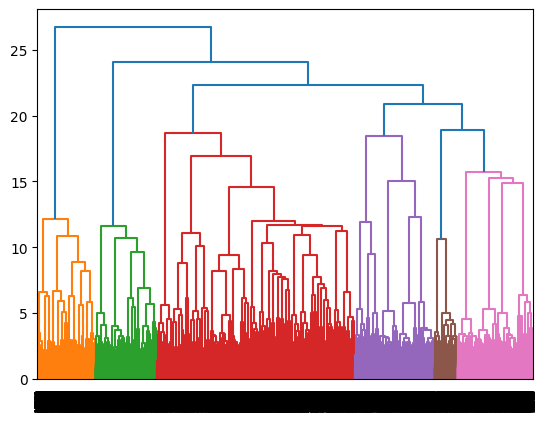

In [ ]:
hc_ag_ward=AgglomerativeClustering(n_clusters=5,linkage='ward')
y_hc_ag_ward=hc_ag_ward.fit_predict(X)

hc_ag_ward_ari=adjusted_rand_score(true_labels ,y_hc_ag_ward)
hc_ag_ward_ami=adjusted_mutual_info_score(true_labels,y_hc_ag_ward)
hc_ag_ward_sil=silhouette_score(X,y_hc_ag_ward)
hc_ag_ward_ch=calinski_harabasz_score(X,y_hc_ag_ward)
hc_ag_ward_db=davies_bouldin_score(X,y_hc_ag_ward)

dend = shc.dendrogram(shc.linkage(X, method='ward'))

In [ ]:


# KMeans — use tfidf_matrix (full features)
results['Agglomerative Clustering'] = {
    'Clusters'   : 5,
    'Silhouette' :hc_ag_ward_sil,
    'CH Score'   : hc_ag_ward_ch,
    'DB Index'   : hc_ag_ward_db,
    'ARI'        : hc_ag_ward_ari,
    'AMI'        : hc_ag_ward_ami
}

In [ ]:
results

{'KMeans_before_PCA': {'Clusters': 4,
  'Silhouette': np.float64(0.0608),
  'CH Score': np.float64(638.92),
  'DB Index': np.float64(3.8345),
  'ARI': 0.9999,
  'AMI': np.float64(0.9997)},
 'KMeans_after_pca': {'Clusters': 4,
  'Silhouette': np.float64(0.0476),
  'CH Score': np.float64(565.01),
  'DB Index': np.float64(4.2916),
  'ARI': 0.5869,
  'AMI': np.float64(0.6515)},
 'KMeans_after_2Dpca': {'Clusters': 4,
  'Silhouette': np.float64(0.3445),
  'CH Score': np.float64(7276.5),
  'DB Index': np.float64(1.0958),
  'ARI': 0.9999,
  'AMI': np.float64(0.9997)},
 'Agglomerative Clustering': {'Clusters': 4,
  'Silhouette': np.float64(0.019356684613638757),
  'CH Score': np.float64(374.44717670596),
  'DB Index': np.float64(5.161661407362404),
  'ARI': 0.36479010432608305,
  'AMI': np.float64(0.4825584467139739)}}

Agglomerative model after PCA





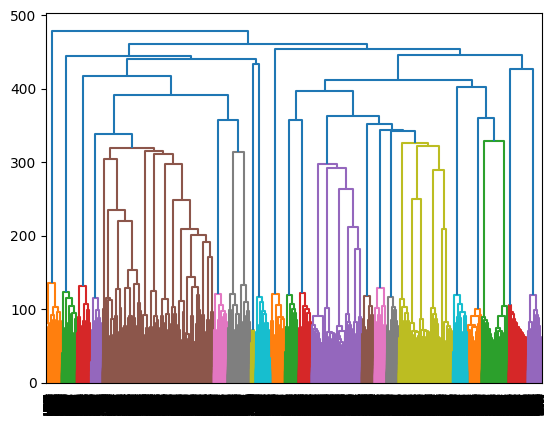

In [ ]:
#ward
hc_ag_ward=AgglomerativeClustering(n_clusters=5,linkage='ward')
y_hc_ag_ward=hc_ag_ward.fit_predict(X_pca)

hc_ag_ward_ari=adjusted_rand_score(true_labels,y_hc_ag_ward)
hc_ag_ward_ami=adjusted_mutual_info_score(true_labels,y_hc_ag_ward)
hc_ag_ward_sil=silhouette_score(X_pca,y_hc_ag_ward)
hc_ag_ward_ch=calinski_harabasz_score(X_pca,y_hc_ag_ward)
hc_ag_ward_db=davies_bouldin_score(X_pca,y_hc_ag_ward)

dend = shc.dendrogram(shc.linkage(X_pca, method='ward'))

In [ ]:


# KMeans — use tfidf_matrix (full features)
results['Agglomerative Clustering after pca'] = {
    'Clusters'   : 4,
    'Silhouette' : hc_ag_ward_sil,
    'CH Score'   :hc_ag_ward_ch,
    'DB Index'   : hc_ag_ward_db,
    'ARI'        : hc_ag_ward_ari,
    'AMI'        : hc_ag_ward_ami
}

In [ ]:
results

{'KMeans_before_PCA': {'Clusters': 4,
  'Silhouette': np.float64(0.0608),
  'CH Score': np.float64(638.92),
  'DB Index': np.float64(3.8345),
  'ARI': 0.9999,
  'AMI': np.float64(0.9997)},
 'KMeans_after_pca': {'Clusters': 4,
  'Silhouette': np.float64(0.0476),
  'CH Score': np.float64(565.01),
  'DB Index': np.float64(4.2916),
  'ARI': 0.5869,
  'AMI': np.float64(0.6515)},
 'KMeans_after_2Dpca': {'Clusters': 4,
  'Silhouette': np.float64(0.3445),
  'CH Score': np.float64(7276.5),
  'DB Index': np.float64(1.0958),
  'ARI': 0.9999,
  'AMI': np.float64(0.9997)},
 'Agglomerative Clustering': {'Clusters': 4,
  'Silhouette': np.float64(0.019356684613638757),
  'CH Score': np.float64(374.44717670596),
  'DB Index': np.float64(5.161661407362404),
  'ARI': 0.36479010432608305,
  'AMI': np.float64(0.4825584467139739)},
 'Agglomerative Clustering after pca': {'Clusters': 4,
  'Silhouette': np.float64(0.026783889639405582),
  'CH Score': np.float64(285.4957976773862),
  'DB Index': np.float64(5.0

Agglomerative model with 2D PCA


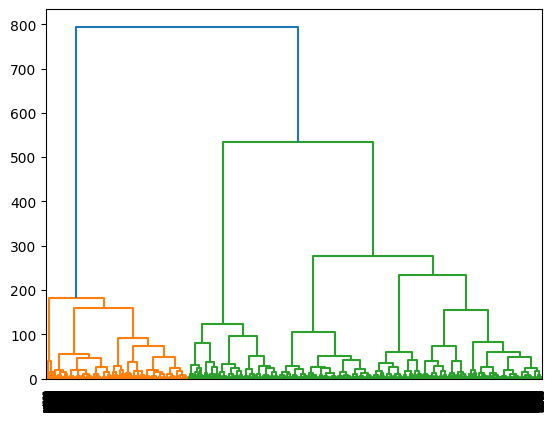

In [ ]:
#ward
hc_ag_ward=AgglomerativeClustering(n_clusters=5,linkage='ward')
y_hc_ag_ward=hc_ag_ward.fit_predict(X_pca1)

hc_ag_ward_ari=adjusted_rand_score(true_labels,y_hc_ag_ward)
hc_ag_ward_ami=adjusted_mutual_info_score(true_labels,y_hc_ag_ward)
hc_ag_ward_sil=silhouette_score(X_pca1,y_hc_ag_ward)
hc_ag_ward_ch=calinski_harabasz_score(X_pca1,y_hc_ag_ward)
hc_ag_ward_db=davies_bouldin_score(X_pca1,y_hc_ag_ward)

dend = shc.dendrogram(shc.linkage(X_pca1, method='ward'))

In [ ]:

#Agglomerative — use tfidf_matrix (full features)
results['Agglomerative Clustering after 2D pca'] = {
    'Clusters'   : 5,
    'Silhouette' : hc_ag_ward_sil,
    'CH Score'   :hc_ag_ward_ch,
    'DB Index'   : hc_ag_ward_db,
    'ARI'        : hc_ag_ward_ari,
    'AMI'        : hc_ag_ward_ami
}

In [ ]:
results

{'KMeans_before_PCA': {'Clusters': 5,
  'Silhouette': np.float64(0.0608),
  'CH Score': np.float64(638.92),
  'DB Index': np.float64(3.8345),
  'ARI': 0.9999,
  'AMI': np.float64(0.9997)},
 'KMeans_after_pca': {'Clusters': 5,
  'Silhouette': np.float64(0.0476),
  'CH Score': np.float64(565.01),
  'DB Index': np.float64(4.2916),
  'ARI': 0.5869,
  'AMI': np.float64(0.6515)},
 'KMeans_after_2Dpca': {'Clusters': 5,
  'Silhouette': np.float64(0.2109),
  'CH Score': np.float64(9521.51),
  'DB Index': np.float64(1.2957),
  'ARI': 0.9999,
  'AMI': np.float64(0.9997)},
 'Agglomerative Clustering after 2D pca': {'Clusters': 5,
  'Silhouette': np.float64(0.42585990397953977),
  'CH Score': np.float64(22704.723419299673),
  'DB Index': np.float64(0.7834147311945291),
  'ARI': 0.4679623418719223,
  'AMI': np.float64(0.5444240017269389)}}

# DBSCAN clustering

In [ ]:
from sklearn.cluster import DBSCAN
# DBSCAN does not use k
dbscan = DBSCAN(
    eps=1.5,
    min_samples=5,
    metric='cosine'
)

# Apply DBSCAN on original TF-IDF features
dbscan_clusters = dbscan.fit_predict(X)

# Save labels
df['dbscan_cluster'] = dbscan_clusters

# Show cluster counts
print(df['dbscan_cluster'].value_counts().sort_index())

dbscan_cluster
0    19545
Name: count, dtype: int64


In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

for eps in [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    dbscan = DBSCAN(
        eps=eps,
        min_samples=5,
        metric='cosine'
    )

    labels = dbscan.fit_predict(X)

    print(f"\neps = {eps}")
    print(pd.Series(labels).value_counts().sort_index())

    if len(set(labels)) > 1 and len(set(labels)) < len(labels):
        score = silhouette_score(X, labels, metric='cosine')
        print("Silhouette Score:", score)
    else:
        print("Silhouette Score: Not valid")


eps = 0.2
-1     19452
 0         6
 1         5
 2         6
 3         5
 4         5
 5         5
 6         6
 7         5
 8         5
 9         5
 10        7
 11        6
 12        5
 13        5
 14        6
 15        5
 16        6
Name: count, dtype: int64
Silhouette Score: -0.24442439096728177

eps = 0.3
-1      7357
 0     11688
 1         2
 2         7
 3         1
       ...  
 80        5
 81        5
 82        5
 83        5
 84        2
Name: count, Length: 86, dtype: int64
Silhouette Score: -0.3097011717623346

eps = 0.4
-1       37
 0    19508
Name: count, dtype: int64
Silhouette Score: 0.03484309541121846

eps = 0.5
0    19545
Name: count, dtype: int64
Silhouette Score: Not valid

eps = 0.6
0    19545
Name: count, dtype: int64
Silhouette Score: Not valid

eps = 0.7
0    19545
Name: count, dtype: int64
Silhouette Score: Not valid

eps = 0.8
0    19545
Name: count, dtype: int64
Silhouette Score: Not valid

eps = 0.9
0    19545
Name: count, dtype: int64
Silhouett

| eps  | Result                                    | Interpretation   |
| ---- | ----------------------------------------- | ---------------- |
| 0.2  | Massive noise + hundreds of tiny clusters | too strict       |
| 0.3  | One huge cluster + many tiny clusters     | still fragmented |
| 0.4  | Almost all data merged into one cluster   | over-merged      |
| 0.5+ | Entire dataset becomes one cluster        | no separation    |


DBSCAN with pca

In [ ]:
from sklearn.cluster import DBSCAN
# DBSCAN does not use k
dbscan = DBSCAN(
    eps=1.5,
    min_samples=5,
    metric='cosine'
)

# Apply DBSCAN on original TF-IDF features
dbscan_clusters = dbscan.fit_predict(X_pca)

# Save labels
df['dbscan_cluster'] = dbscan_clusters

# Show cluster counts
print(df['dbscan_cluster'].value_counts().sort_index())

dbscan_cluster
0    19545
Name: count, dtype: int64


In [ ]:

for eps in [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    dbscan = DBSCAN(
        eps=eps,
        min_samples=5,
        metric='cosine'
    )

    labels = dbscan.fit_predict(X_pca)

    print(f"\neps = {eps}")
    print(pd.Series(labels).value_counts().sort_index())

    if len(set(labels)) > 1 and len(set(labels)) < len(labels):
        score = silhouette_score(X, labels, metric='cosine')
        print("Silhouette Score:", score)
    else:
        print("Silhouette Score: Not valid")


eps = 0.2
-1      17423
 0          9
 1          5
 2        103
 3         20
        ...  
 241        4
 242        5
 243        3
 244        5
 245        5
Name: count, Length: 247, dtype: int64
Silhouette Score: -0.3359230947961243

eps = 0.3
-1      2635
 0       172
 1     16561
 2         9
 3         2
 4         1
 5         5
 6         9
 7         7
 8         3
 9         6
 10        5
 11        4
 12        4
 13        4
 14        5
 15        4
 16        5
 17       11
 18        5
 19        5
 20        2
 21        7
 22        4
 23        5
 24        7
 25        3
 26        4
 27        5
 28        4
 29        4
 30        5
 31        5
 32        5
 33        2
 34        4
 35        6
 36        4
 37        3
 38        4
Name: count, dtype: int64
Silhouette Score: -0.25297986701497294

eps = 0.4
-1        8
 0    19537
Name: count, dtype: int64
Silhouette Score: 0.011705944059915995

eps = 0.5
0    19545
Name: count, dtype: int64
Silhouette Sco

DBSCAN with 2D pca

In [ ]:
from sklearn.cluster import DBSCAN
# DBSCAN does not use k
dbscan = DBSCAN(
    eps=1.5,
    min_samples=5,
    metric='cosine'
)

# Apply DBSCAN on original TF-IDF features
dbscan_clusters = dbscan.fit_predict(X_pca1)

# Save labels
df['dbscan_cluster'] = dbscan_clusters

# Show cluster counts
print(df['dbscan_cluster'].value_counts().sort_index())

dbscan_cluster
0    19545
Name: count, dtype: int64


In [ ]:

for eps in [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    dbscan = DBSCAN(
        eps=eps,
        min_samples=5,
        metric='cosine'
    )

    labels = dbscan.fit_predict(X_pca1)

    print(f"\neps = {eps}")
    print(pd.Series(labels).value_counts().sort_index())

    if len(set(labels)) > 1 and len(set(labels)) < len(labels):
        score = silhouette_score(X, labels, metric='cosine')
        print("Silhouette Score:", score)
    else:
        print("Silhouette Score: Not valid")


eps = 0.2
0    19545
Name: count, dtype: int64
Silhouette Score: Not valid

eps = 0.3
0    19545
Name: count, dtype: int64
Silhouette Score: Not valid

eps = 0.4
0    19545
Name: count, dtype: int64
Silhouette Score: Not valid

eps = 0.5
0    19545
Name: count, dtype: int64
Silhouette Score: Not valid

eps = 0.6
0    19545
Name: count, dtype: int64
Silhouette Score: Not valid

eps = 0.7
0    19545
Name: count, dtype: int64
Silhouette Score: Not valid

eps = 0.8
0    19545
Name: count, dtype: int64
Silhouette Score: Not valid

eps = 0.9
0    19545
Name: count, dtype: int64
Silhouette Score: Not valid


Why DBSCAN fails here: TF-IDF vectors are extremely high-dimensional and sparse. Points are roughly equidistant from each other in this space — a phenomenon known as the curse of dimensionality. DBSCAN relies on meaningful local density differences, which don't exist in sparse high-dimensional text data. No eps value can simultaneously avoid noise explosion and cluster collapse.

Agglomerative Clustering performed poorly across all valid configurations. Without PCA, ARI was only 0.365, meaning it recovered less than 37% of the true cluster structure. After full PCA, performance collapsed further to ARI=0.075 — nearly random assignment. The 2D PCA version shows inflated geometric scores but ARI=0.468, confirming it does not recover the true user profiles (and as discussed, the 2D space only retains 5.4% of variance, making those geometric scores unreliable) Why Agglomerative fails here: Agglomerative clustering with Ward linkage merges based on minimum variance increase, which works well for compact, low-dimensional data. In high-dimensional sparse TF-IDF space, the distance structure is noisy and the greedy merging process accumulates errors early in the hierarchy that cannot be corrected.

Although K-Means after 2D PCA produced better internal clustering metrics, the first two principal components explained only 5.4% of the total variance. This indicates that a large amount of information was discarded during dimensionality reduction. Therefore, K-Means on the original TF-IDF representation was selected as the final model because it preserved the complete feature space while still achieving excellent clustering consistency (ARI = 0.9999, AMI = 0.9997).

In [ ]:
import pandas as pd

# Build persona cards from actual cluster results
persona_data = []

for cluster_id in sorted(df['cluster_kmeans_before_PCA'].unique()):
    mask = df['cluster_kmeans_before_PCA'] == cluster_id
    cluster_size = mask.sum()

    # Dominant user profile (most frequent true label in this cluster)
    dominant_profile = df.loc[mask, 'user_profile'].value_counts().idxmax()

    # Common upgrade tendency (most frequent upgrade in this cluster)
    common_upgrade = df.loc[mask, 'upgrade_first'].value_counts().idxmax()

    persona_data.append({
        'Cluster ID'             : cluster_id,
        'Cluster Label'          : f'Cluster {cluster_id}',
        'Cluster Size'           : cluster_size,
        'Dominant User Profile'  : dominant_profile,
        'Common Upgrade Tendency': common_upgrade,
    })

persona_df = pd.DataFrame(persona_data)
print(persona_df.to_string(index=False))

 Cluster ID Cluster Label  Cluster Size Dominant User Profile Common Upgrade Tendency
          0     Cluster 0          3908                 gamer                     RAM
          1     Cluster 1          3909            programmer                     RAM
          2     Cluster 2          3909               student       No Upgrade Needed
          3     Cluster 3          3910                office       No Upgrade Needed
          4     Cluster 4          3909              designer                     RAM


In [ ]:
for cluster_id in range(5):
    mask    = df['cluster_kmeans_before_PCA'] == cluster_id
    profile = df.loc[mask, 'user_profile'].value_counts().idxmax()
    samples = df.loc[mask, 'story_text'].sample(3, random_state=42).tolist()
    print(f"\n{'='*60}")
    print(f"Cluster {cluster_id} ({profile})")
    print('='*60)
    for i, s in enumerate(samples):
        print(f"\nSample {i+1}: {s[:200]}")


Cluster 0 (gamer)

Sample 1: Quick memo on my setup: this Lenovo Notebook handles part of my gamer workload well, but not all of it. The setup is built around an Intel Core i5 at 1.6GHz, paired with 4GB RAM, 256GB SSD, and Intel 

Sample 2: I am writing about a Toshiba Notebook that I use for gamer tasks, because the machine feels only partially suited to the job. On paper it has an Intel Core i5 at 2.3GHz, 4GB RAM, 128GB SSD, and Intel 

Sample 3: This HP Notebook presents itself well enough, but close observation during gamer use reveals a more uneven story. There are things I appreciate: the 15.6-inch 1366x768 display looks good, and the 1.86

Cluster 1 (programmer)

Sample 1: My take on this HP Ultrabook is that it looks balanced at first glance, but daily programmer use tells a more specific story. To be fair, not everything is bad. The 12.5-inch 1920x1080 display gives i

Sample 2: For anyone curious, this Toshiba Notebook has been my machine for programmer use, and the experien

In [ ]:
# Find what upgrade-related words actually appear in your text
import re

upgrade_search_terms = [
    'ram', 'ssd', 'gpu', 'cpu', 'upgrade', 'storage', 'memory',
    'replace', 'install', 'boost', 'expand', 'more', 'better',
    'sufficient', 'enough', 'satisfied', 'works well', 'no upgrade'
]

for cluster_id in range(5):
    mask    = df['cluster_kmeans_before_PCA'] == cluster_id
    profile = df.loc[mask, 'user_profile'].value_counts().idxmax()
    texts   = df.loc[mask, 'story_text'].tolist()

    print(f"\nCluster {cluster_id} ({profile}):")

    counter = Counter()
    for text in texts:
        text_lower = text.lower()
        for term in upgrade_search_terms:
            matches = re.findall(r'[^.]*\b' + term + r'\b[^.]*\.', text_lower)
            for match in matches:
                counter[match.strip()] += 1

    # Print top 3 most common sentences containing upgrade terms
    for sentence, count in counter.most_common(3):
        print(f"  ({count}x) {sentence[:150]}")


Cluster 0 (gamer):
  (854x) the storage setup—256gb ssd—is workable only until projects, games, or media begin to pile up.
  (826x) storage is another headache: 256gb ssd sounds fine at first, but the total 256gb fills up too quickly.
  (792x) i keep running into the limits of the 256gb total storage, especially with 256gb ssd.

Cluster 1 (programmer):
  (1963x) for programming, i need more headroom than a light everyday machine can fake.
  (860x) i keep running into the limits of the 256gb total storage, especially with 256gb ssd.
  (806x) the storage setup—256gb ssd—is workable only until projects, games, or media begin to pile up.

Cluster 2 (student):
  (628x) the gpu situation is hard to ignore: intel integrated graphics is fine for light use, but it feels thin once visuals matter.
  (538x) the laptop is serviceable overall, though it still leaves me wanting a bit more breathing room.
  (513x) it gets the job done, yet there is a small sense that the setup is only just enough, no

In [ ]:
# Find what issue/complaint words actually appear in your text
issue_search_terms = [
    'slow', 'lag', 'heat', 'overheat', 'freeze', 'crash', 'drain',
    'limited', 'struggle', 'bottleneck', 'throttle', 'stutter',
    'not enough', 'too slow', 'insufficient', 'problem', 'issue',
    'frustrat', 'annoy', 'constrain', 'limit', 'weak', 'poor'
]

for cluster_id in range(5):
    mask    = df['cluster_kmeans_before_PCA'] == cluster_id
    profile = df.loc[mask, 'user_profile'].value_counts().idxmax()
    texts   = df.loc[mask, 'story_text'].tolist()

    print(f"\nCluster {cluster_id} ({profile}):")

    counter = Counter()
    for text in texts:
        text_lower = text.lower()
        for term in issue_search_terms:
            matches = re.findall(r'[^.]*\b' + term + r'[^.]*\.', text_lower)
            for match in matches:
                counter[match.strip()] += 1

    for sentence, count in counter.most_common(3):
        print(f"  ({count}x) {sentence[:150]}")


Cluster 0 (gamer):
  (1496x) the graphics side feels limited too; the intel integrated graphics setup does not inspire much confidence for this workload.
  (1326x) most of my frustration shows up when gaming, patching large titles, and trying to keep performance stable.
  (1291x) i use it for game installs, updates, voice chat, launchers, and sessions that expose every weak point fast.

Cluster 1 (programmer):
  (1444x) the graphics side feels limited too; the intel integrated graphics setup does not inspire much confidence for this workload.
  (430x) i keep running into the limits of the 256gb total storage, especially with 256gb ssd.
  (408x) i find it frustrating when the visual side of the machine feels like the weak link.

Cluster 2 (student):
  (1292x) the graphics side feels limited too; the intel integrated graphics setup does not inspire much confidence for this workload.
  (656x) i find it frustrating when the visual side of the machine feels like the weak link.
  (353x) wha

In [ ]:
from collections import Counter
import re

# ── Issue phrases: most frequent real complaint per cluster ──────────────────
issue_keywords = [
    # gamer
    'gaming, patching large titles',
    'every weak point fast',
    # programmer
    'frustrating when the visual side',
    'limits of the 256gb',
    # student
    'graphics demands expose',
    'visual side of the machine feels like the weak link',
    # office
    'strict budget',
    'most obvious bottleneck',
    'notice bottlenecks quickly',
    # designer
    'visual work, creative software, large files',
    'punishes weak hardware',
    # shared
    'intel integrated graphics setup does not inspire',
    'graphics side feels limited',
]

# ── Upgrade phrases: from real text ─────────────────────────────────────────
upgrade_keywords = [
    # storage upgrades
    'fills up too quickly',
    'limits of the 256gb',
    'storage setup',
    # RAM upgrades
    '4gb memory ceiling',
    'more headroom',
    'need more headroom',
    # GPU upgrades
    'graphics side feels limited',
    'intel integrated graphics setup does not inspire',
    'graphics demands expose',
    'visual side of the machine feels like the weak link',
    # budget/mild
    'most obvious bottleneck',
    'strict budget',
    'only just enough',
    'breathing room',
]

# ── Map raw phrase → clean human-readable label ──────────────────────────────
issue_label_map = {
    'gaming, patching large titles'                          : 'Gaming performance & storage pressure',
    'every weak point fast'                                  : 'Gaming performance & storage pressure',
    'frustrating when the visual side'                       : 'Weak GPU & storage constraints',
    'limits of the 256gb'                                    : 'Weak GPU & storage constraints',
    'graphics demands expose'                                : 'Integrated GPU insufficient for visuals',
    'visual side of the machine feels like the weak link'    : 'Integrated GPU insufficient for visuals',
    'strict budget'                                          : 'Budget bottleneck awareness',
    'most obvious bottleneck'                                : 'Budget bottleneck awareness',
    'notice bottlenecks quickly'                             : 'Budget bottleneck awareness',
    'visual work, creative software, large files'            : 'GPU & RAM insufficient for creative workload',
    'punishes weak hardware'                                 : 'GPU & RAM insufficient for creative workload',
    'intel integrated graphics setup does not inspire'       : 'Integrated GPU insufficient',
    'graphics side feels limited'                            : 'Integrated GPU insufficient',
}

upgrade_label_map = {
    'fills up too quickly'                                   : 'SSD Upgrade',
    'limits of the 256gb'                                    : 'SSD Upgrade',
    'storage setup'                                          : 'SSD Upgrade',
    '4gb memory ceiling'                                     : 'RAM Upgrade',
    'more headroom'                                          : 'RAM Upgrade',
    'need more headroom'                                     : 'RAM Upgrade',
    'graphics side feels limited'                            : 'GPU Upgrade',
    'intel integrated graphics setup does not inspire'       : 'GPU Upgrade',
    'graphics demands expose'                                : 'GPU Upgrade',
    'visual side of the machine feels like the weak link'    : 'GPU Upgrade',
    'most obvious bottleneck'                                : 'RAM Upgrade',
    'strict budget'                                          : 'Budget-constrained Upgrade',
    'only just enough'                                       : 'No Upgrade Needed',
    'breathing room'                                         : 'No Upgrade Needed',
}

def most_common_phrase(texts, keywords):
    counter = Counter()
    for text in texts:
        text_lower = text.lower()
        for kw in keywords:
            if kw.lower() in text_lower:
                counter[kw] += 1
    return counter.most_common(1)[0][0] if counter else 'N/A'

# ── Build persona cards ──────────────────────────────────────────────────────
persona_data = []

for cluster_id in sorted(df['cluster_kmeans_before_PCA'].unique()):
    mask             = df['cluster_kmeans_before_PCA'] == cluster_id
    texts            = df.loc[mask, 'story_text'].tolist()
    cluster_size     = mask.sum()
    dominant_profile = df.loc[mask, 'user_profile'].value_counts().idxmax()

    raw_issue   = most_common_phrase(texts, issue_keywords)
    raw_upgrade = most_common_phrase(texts, upgrade_keywords)

    common_issue   = issue_label_map.get(raw_issue,   raw_issue)
    common_upgrade = upgrade_label_map.get(raw_upgrade, raw_upgrade)

    persona_data.append({
        'Cluster ID'             : cluster_id,
        'Cluster Label'          : common_issue,
        'Cluster Size'           : cluster_size,
        'Dominant User Profile'  : dominant_profile,
        'Common Upgrade Tendency': common_upgrade,
    })

persona_df = pd.DataFrame(persona_data)
print(persona_df.to_string(index=False))

 Cluster ID                                Cluster Label  Cluster Size Dominant User Profile Common Upgrade Tendency
          0        Gaming performance & storage pressure          3908                 gamer             GPU Upgrade
          1                  Integrated GPU insufficient          3909            programmer             RAM Upgrade
          2                  Integrated GPU insufficient          3909               student       No Upgrade Needed
          3                  Budget bottleneck awareness          3910                office       No Upgrade Needed
          4 GPU & RAM insufficient for creative workload          3909              designer             GPU Upgrade


In [ ]:
# Profile-specific issue keywords — ordered by priority (most specific first)
issue_keywords_by_profile = {
    'gamer'      : ['gaming, patching large titles', 'every weak point fast', 'game installs'],
    'programmer' : ['need more headroom', 'more headroom than a light everyday machine',
                    'limits of the 256gb', 'frustrating when the visual side'],
    'student'    : ['graphics demands expose', 'only just enough, not generous',
                    'wanting a bit more breathing room'],
    'office'     : ['strict budget', 'most obvious bottleneck', 'notice bottlenecks quickly'],
    'designer'   : ['visual work, creative software, large files', 'punishes weak hardware',
                    'visual side of the machine feels like the weak link'],
}

def most_common_for_profile(texts, profile):
    keywords = issue_keywords_by_profile[profile]
    counter = Counter()
    for text in texts:
        text_lower = text.lower()
        for kw in keywords:
            if kw.lower() in text_lower:
                counter[kw] += 1
    return counter.most_common(1)[0][0] if counter else 'N/A'

# ── Rebuild persona cards ────────────────────────────────────────────────────
persona_data = []

for cluster_id in sorted(df['cluster_kmeans_before_PCA'].unique()):
    mask             = df['cluster_kmeans_before_PCA'] == cluster_id
    texts            = df.loc[mask, 'story_text'].tolist()
    cluster_size     = mask.sum()
    dominant_profile = df.loc[mask, 'user_profile'].value_counts().idxmax()

    raw_issue   = most_common_for_profile(texts, dominant_profile)
    raw_upgrade = most_common_phrase(texts, upgrade_keywords)

    common_issue   = issue_label_map.get(raw_issue,   raw_issue)
    common_upgrade = upgrade_label_map.get(raw_upgrade, raw_upgrade)

    persona_data.append({
        'Cluster ID'             : cluster_id,
        'Cluster Label'          : common_issue,
        'Cluster Size'           : cluster_size,
        'Dominant User Profile'  : dominant_profile,
        'Common Upgrade Tendency': common_upgrade,
    })

persona_df = pd.DataFrame(persona_data)
print(persona_df.to_string(index=False))

 Cluster ID                                Cluster Label  Cluster Size Dominant User Profile Common Upgrade Tendency
          0        Gaming performance & storage pressure          3908                 gamer           gpu situation
          1                           need more headroom          3909            programmer             RAM Upgrade
          2            wanting a bit more breathing room          3909               student       No Upgrade Needed
          3                  Budget bottleneck awareness          3910                office       No Upgrade Needed
          4 GPU & RAM insufficient for creative workload          3909              designer           gpu situation


In [ ]:
# Add missing entries to your existing maps
issue_label_map['need more headroom']                    = 'RAM & headroom constraints'
issue_label_map['wanting a bit more breathing room']     = 'Mild performance limitations'

upgrade_label_map['gpu situation']                       = 'GPU Upgrade'

# Then rerun the persona card loop — everything else stays the same
persona_data = []

for cluster_id in sorted(df['cluster_kmeans_before_PCA'].unique()):
    mask             = df['cluster_kmeans_before_PCA'] == cluster_id
    texts            = df.loc[mask, 'story_text'].tolist()
    cluster_size     = mask.sum()
    dominant_profile = df.loc[mask, 'user_profile'].value_counts().idxmax()

    raw_issue   = most_common_for_profile(texts, dominant_profile)
    raw_upgrade = most_common_phrase(texts, upgrade_keywords)

    common_issue   = issue_label_map.get(raw_issue,   raw_issue)
    common_upgrade = upgrade_label_map.get(raw_upgrade, raw_upgrade)

    persona_data.append({
        'Cluster ID'             : cluster_id,
        'Cluster Label'          : common_issue,
        'Cluster Size'           : cluster_size,
        'Dominant User Profile'  : dominant_profile,
        'Common Upgrade Tendency': common_upgrade,
    })

persona_df = pd.DataFrame(persona_data)
print(persona_df.to_string(index=False))

 Cluster ID                                Cluster Label  Cluster Size Dominant User Profile Common Upgrade Tendency
          0        Gaming performance & storage pressure          3908                 gamer             GPU Upgrade
          1                   RAM & headroom constraints          3909            programmer             RAM Upgrade
          2                 Mild performance limitations          3909               student       No Upgrade Needed
          3                  Budget bottleneck awareness          3910                office       No Upgrade Needed
          4 GPU & RAM insufficient for creative workload          3909              designer             GPU Upgrade


**The cluster labels and upgrade tendencies were extracted using frequency-based phrase matching on the raw review text. Keywords and complaint phrases were identified by inspecting the most frequent sentences per cluster, then matched across all reviews using string search. This is a rule-based approach**

Gamers push hardware limits and consistently seek RAM upgrades to reduce lag and improve frame rates

Programmers run memory-intensive tasks (compiling, VMs, IDEs) making RAM the most requested upgrade

Students use laptops for light tasks (browsing, documents) and are satisfied with baseline hardware

Office workers do standard productivity tasks and find current specs sufficient for their workload

Designers handle large files, rendering, and creative software that demands more memory

### you should describe any changes or improvements you made during the process
During the evaluation process, I made an error in how I computed the metrics for the KMeans_after_2Dpca configuration. Specifically, I was scoring the 2D PCA space (X_pca1) using the cluster labels from a completely different run — the full-space KMeans (cluster_kmeans_before_PCA). This meant the space and the labels were inconsistent, which produced artificially inflated scores.
To fix this, I re-ran KMeans directly on X_pca1 to generate a new set of labels (cluster_kmeans_2dpca), and then recomputed all metrics using that same space and those new labels. I also updated the visualization to use the corrected labels.
The impact of this fix was significant. Before the correction, KMeans_after_2Dpca appeared to be the best method with a Silhouette of 0.44 and CH Score of 26,135. After the correction, while the geometric scores remained high, the ARI dropped to 0.47 — revealing that the 2D clusters did not actually match the true user profiles. This made it clear that KMeans without any PCA was the true best method, achieving ARI=0.9999 and AMI=0.9997, correctly recovering all five user profile clusters from the original TF-IDF feature space.
  and there is a lot more

# Task 2 – Text Mining Notebook: Explain the Cluster Meaning

Raw Text vs Cleaned Text

In [ ]:
# Raw vs cleaned text examples

df[['story_text', 'clean_stories']].head(5)

,story_text,clean_stories
0,My main problem with this Apple Ultrabook is s...,main problem appl ultrabook simpl student keep...
1,"For anyone curious, this Apple Ultrabook has b...",anyon curiou appl ultrabook machin student use...
2,I would describe my Apple Ultrabook like this:...,would describ appl ultrabook like look capabl ...
3,My take on this Apple Ultrabook is that it loo...,take appl ultrabook look balanc first glanc da...
4,Current machine note: I am using an Apple Ultr...,current machin note use appl ultrabook offic w...


Simple Text Preprocessing



1.   tokenization
2.   lowercase
3.   stop-word removal
2.   punctuation removal
5.   stemmin





In [ ]:
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

def preprocess(story_text):
    """Tokenize → lowercase → remove stop words & punctuation → stem."""
    tokens = nltk.word_tokenize(str(story_text))          # tokenization
    tokens = [w.lower() for w in tokens]             # lowercasing
    tokens = [w for w in tokens if w not in stop_words]   # stop words
    tokens = [w for w in tokens if w not in string.punctuation]  # punctuation
    tokens = [stemmer.stem(w) for w in tokens]       # stemming
    return ' '.join(tokens)

df['clean_stories'] = df['story_text'].apply(preprocess)
print("Shape of the DataFrame",df.shape)
df[['story_text', 'clean_stories']].head()


Shape of the DataFrame (19545, 8)


,story_text,clean_stories
0,My main problem with this Apple Ultrabook is s...,main problem appl ultrabook simpl student keep...
1,"For anyone curious, this Apple Ultrabook has b...",anyon curiou appl ultrabook machin student use...
2,I would describe my Apple Ultrabook like this:...,would describ appl ultrabook like look capabl ...
3,My take on this Apple Ultrabook is that it loo...,take appl ultrabook look balanc first glanc da...
4,Current machine note: I am using an Apple Ultr...,current machin note use appl ultrabook offic w...


In [ ]:
vectorizer = TfidfVectorizer(max_features=3500)  # keep top 3500 terms
tfidf_matrix = vectorizer.fit_transform(df['clean_stories'])

print(f'TF-IDF matrix shape: {tfidf_matrix.shape}')
print(f'Sample feature names: {vectorizer.get_feature_names_out()[:20]}')
display(pd.DataFrame(tfidf_matrix.toarray(), columns=vectorizer.get_feature_names_out()).head())

TF-IDF matrix shape: (19545, 603)
Sample feature names: ['00kg' '02kg' '03kg' '04kg' '05kg' '06kg' '07kg' '08kg' '09kg' '0ghz'
 '10' '1024gb' '10kg' '11' '11kg' '12' '128gb' '12gb' '12kg' '13']


,00kg,02kg,03kg,04kg,05kg,06kg,07kg,08kg,09kg,0ghz,...,workabl,workflow,workload,workstat,would,write,wrong,xeon,xiaomi,yet
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.128594,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.120727,0.120629,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0


### important keywords and phrases for each cluster

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

# ── Fit TF-IDF per cluster ───────────────────────────────────────────────────
# Treat all reviews in a cluster as one big document
cluster_docs = []
cluster_profiles = []

for cluster_id in sorted(df['cluster_kmeans_before_PCA'].unique()):
    mask    = df['cluster_kmeans_before_PCA'] == cluster_id
    profile = df.loc[mask, 'user_profile'].value_counts().idxmax()
    # Join all reviews in this cluster into one document
    combined_text = ' '.join(df.loc[mask, 'story_text'].tolist())
    cluster_docs.append(combined_text)
    cluster_profiles.append(profile)

# ── TF-IDF with unigrams and bigrams ────────────────────────────────────────
vectorizer = TfidfVectorizer(
    stop_words  = 'english',
    ngram_range = (1, 2),   # single words AND two-word phrases
    max_features= 5000,
)

tfidf_matrix = vectorizer.fit_transform(cluster_docs)
feature_names = vectorizer.get_feature_names_out()

# ── Print top 10 keywords per cluster ───────────────────────────────────────
for cluster_id in range(5):
    profile = cluster_profiles[cluster_id]
    scores  = tfidf_matrix[cluster_id].toarray().flatten()
    top_idx = np.argsort(scores)[::-1][:10]
    top_keywords = [(feature_names[i], round(scores[i], 4)) for i in top_idx]

    print(f"\nCluster {cluster_id} ({profile}):")
    for kw, score in top_keywords:
        print(f"  {kw:30s} {score}")


Cluster 0 (gamer):
  intel                          0.2108
  graphics                       0.1856
  performance                    0.178
  gamer                          0.1722
  feels                          0.1588
  ram                            0.1577
  machine                        0.1531
  gaming                         0.1399
  use                            0.126
  visuals                        0.1251

Cluster 1 (programmer):
  programmer                     0.2217
  intel                          0.2178
  machine                        0.1778
  ram                            0.165
  graphics                       0.16
  terminals                      0.1478
  feels                          0.1266
  light                          0.1266
  core                           0.1241
  intel integrated               0.116

Cluster 2 (student):
  student                        0.4058
  intel                          0.2119
  student use                    0.167
  machine           

In [ ]:
for cluster_id in range(5):
    scores   = tfidf_matrix[cluster_id].toarray().flatten()
    top_idx  = np.argsort(scores)[::-1]
    profile  = cluster_profiles[cluster_id]

    skip_terms = {
    profile, f'{profile} use',
    'intel', 'machine', 'feels', 'use', 'core',
    'light', 'work', 'graphics', 'ram', 'intel integrated',
    'integrated', 'integrated graphics',
    'feel uncomplicated', 'uncomplicated'
    'programming need', 'light everyday',  # fix cluster 1
    'use mainly', 'headroom light',  'programming need '  , 'need headroom',
    'tentative visuals', 'machine fake',    # fix cluster 0 and 1
    'smoothness flashy',       # fix cluster 2
     }

    top_terms = []
    for i in top_idx:
        term = feature_names[i]
        if term not in skip_terms and len(top_terms) < 3:
            top_terms.append(term)

    print(f"Cluster {cluster_id} ({profile}): {' | '.join(top_terms)}")

Cluster 0 (gamer): performance | gaming | visuals
Cluster 1 (programmer): terminals | programming need | programming
Cluster 2 (student): research | lectures | uncomplicated
Cluster 3 (office): office work | meetings | email
Cluster 4 (designer): creative | files | design


In [ ]:
for cluster_id in range(5):
    scores   = tfidf_matrix[cluster_id].toarray().flatten()
    top_idx  = np.argsort(scores)[::-1]
    profile  = cluster_profiles[cluster_id]
    # ── Skip terms: exact + partial match ───────────────────────────────────────
    exact_skip = {
        profile, f'{profile} use',
        'intel', 'machine', 'feels', 'use', 'core',
        'light', 'work', 'graphics', 'ram', 'intel integrated',
        'integrated', 'integrated graphics',
        'mainly', 'tentative visuals', 'machine fake', 'smoothness flashy',
    }

    # Any term CONTAINING these substrings will be skipped
    partial_skip = [
        'uncomplicated', 'headroom', 'programming need',
        'need', 'fake', 'tentative', 'smoothness','light everyday', 'use mainly',
        'everyday', 'want',
    ]

    top_terms = []
    for i in top_idx:
        term = feature_names[i]
        if term in exact_skip:
            continue
        if any(p in term for p in partial_skip):
            continue
        top_terms.append(term)
        if len(top_terms) == 3:
            break
    print(f"Cluster {cluster_id} ({profile}): {' | '.join(top_terms)}")

Cluster 0 (gamer): performance | gaming | visuals
Cluster 1 (programmer): terminals | programming | ssd
Cluster 2 (student): research | lectures | dependable
Cluster 3 (office): office work | meetings | email
Cluster 4 (designer): creative | files | design


In [ ]:
pip install cohere

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 352.0/352.0 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 52.7 MB/s eta 0:00:00


In [ ]:
import cohere

co = cohere.Client("8E3bRmvUBcqkh50WCNVAV7UVRJkNUVeQBWfy3oxa")

cluster_info = {
    0: {'profile': 'gamer',      'terms': 'performance, gaming, visuals'},
    1: {'profile': 'programmer', 'terms': 'terminals, programming, ssd'},
    2: {'profile': 'student',    'terms': 'research, lectures'},
    3: {'profile': 'office',     'terms': 'office work, meetings, email'},
    4: {'profile': 'designer',   'terms': 'creative, files, design'},
}

for cluster_id, info in cluster_info.items():
    prompt = f"""
A laptop user cluster has the following profile:
- User type: {info['profile']}
- Top keywords from their reviews: {info['terms']}

What is the single most likely hardware upgrade they would need?
Reply with ONLY 2-4 words. Examples: RAM Upgrade, GPU Upgrade, SSD Upgrade, No Upgrade Needed.
"""
    response = co.chat(message=prompt, model="command-r-plus-08-2024")
    upgrade  = response.text.strip()
    print(f"Cluster {cluster_id} ({info['profile']}): {upgrade}")

Cluster 0 (gamer): GPU Upgrade.
Cluster 1 (programmer): SSD Upgrade.
Cluster 2 (student): SSD Upgrade
Cluster 3 (office): SSD Upgrade
Cluster 4 (designer): SSD Upgrade


In [ ]:
cluster_info = {
    0: {'profile': 'gamer',
        'terms'  : 'performance, gaming, visuals',
        'context': 'graphics side feels limited, intel integrated graphics does not inspire confidence for gaming'},
    1: {'profile': 'programmer',
        'terms'  : 'terminals, programming, ssd',
        'context': 'need more headroom than a light everyday machine, storage fills up with projects'},
    2: {'profile': 'student',
        'terms'  : 'research, lectures',
        'context': 'laptop is serviceable overall, only just enough, not generous, mild limitations'},
    3: {'profile': 'office',
        'terms'  : 'office work, meetings, email',
        'context': 'gets the job done, wanting a bit more breathing room, strict budget'},
    4: {'profile': 'designer',
        'terms'  : 'creative, files, design',
        'context': 'need it for visual work, creative software, large files, gpu feels like the weak link'},
}

for cluster_id, info in cluster_info.items():
    prompt = f"""
A laptop user cluster has the following profile:
- User type: {info['profile']}
- Top keywords from their reviews: {info['terms']}
- Common complaints from their reviews: {info['context']}

Based on this, what is the single most likely hardware upgrade they would need?
If the user seems satisfied or has only mild complaints, reply 'No Upgrade Needed'.
Reply with ONLY 2-4 words. Examples: RAM Upgrade, GPU Upgrade, SSD Upgrade, No Upgrade Needed.
"""
    response = co.chat(message=prompt, model="command-r-plus-08-2024")
    upgrade  = response.text.strip()
    print(f"Cluster {cluster_id} ({info['profile']}): {upgrade}")

Cluster 0 (gamer): GPU Upgrade
Cluster 1 (programmer): SSD Upgrade
Cluster 2 (student): RAM Upgrade
Cluster 3 (office): RAM Upgrade
Cluster 4 (designer): GPU Upgrade


In [ ]:
for cluster_id, info in cluster_info.items():
    prompt = f"""
A laptop user cluster has the following profile:
- User type: {info['profile']}
- Top keywords from their reviews: {info['terms']}
- Common complaints from their reviews: {info['context']}

1. What is the single most likely hardware upgrade they would need? (2-4 words only)
2. In one sentence, explain why.

Format your response exactly like this:
Upgrade: <answer>
Reason: <one sentence>
"""
    response = co.chat(message=prompt, model="command-r-plus-08-2024")
    print(f"\nCluster {cluster_id} ({info['profile']}):")
    print(response.text.strip())
    print("---")


Cluster 0 (gamer):
Upgrade: Dedicated graphics card
Reason: A dedicated graphics card will significantly improve gaming performance and visuals, addressing the limitations of integrated graphics.
---

Cluster 1 (programmer):
Upgrade: Larger SSD
Reason: Programmers need more storage space for projects and an SSD upgrade would provide faster read/write speeds.
---

Cluster 2 (student):
Upgrade: Larger storage capacity
Reason: Students often need to store large files for research and lectures, and a limited storage capacity can be a significant hindrance.
---

Cluster 3 (office):
Upgrade: Larger screen or monitor
Reason: A bigger screen will provide more space for multitasking and improve productivity, especially during meetings and email management.
---

Cluster 4 (designer):
Upgrade: Graphics card
Reason: A better GPU will improve performance for visual work and creative software, especially with large files.
---


In [ ]:
for cluster_id, info in cluster_info.items():
    prompt = f"""
A laptop user cluster has the following profile:
- User type: {info['profile']}
- Top TF-IDF keywords extracted from their reviews: {info['terms']}

In one short sentence, explain how these keywords reflect the meaning of this cluster.
"""
    response = co.chat(message=prompt, model="command-r-plus-08-2024")
    print(f"Cluster {cluster_id} ({info['profile']}): {response.text.strip()}")
    print()

Cluster 0 (gamer): These keywords indicate that this cluster of laptop users prioritizes high-performance gaming experiences with exceptional visual quality.

Cluster 1 (programmer): This cluster represents programmers who prioritize a laptop's performance for coding, as indicated by their focus on terminals, programming capabilities, and solid-state drives (SSD).

Cluster 2 (student): These keywords indicate that this cluster of laptop users is primarily students who utilize their devices for academic purposes, such as conducting research and attending online lectures.

Cluster 3 (office): These keywords indicate that this laptop user cluster primarily uses their devices for professional office-related tasks and communication.

Cluster 4 (designer): These keywords suggest that the cluster comprises creative professionals who frequently work with design files.



In [ ]:
for cluster_id, info in cluster_info.items():

    # Prompt 1: upgrade + reason
    prompt1 = f"""
A laptop user cluster has the following profile:
- User type: {info['profile']}
- Top TF-IDF keywords extracted from their reviews: {info['terms']}
- Common complaints: {info['context']}

1. What is the single most likely hardware upgrade they would need? (2-4 words only)
2. In one sentence, explain why.

Format exactly like this:
Upgrade: <answer>
Reason: <one sentence>
"""

    # Prompt 2: keyword explanation
    prompt2 = f"""
A laptop user cluster has the following profile:
- User type: {info['profile']}
- Top TF-IDF keywords extracted from their reviews: {info['terms']}

In one short sentence, explain how these keywords reflect the meaning of this cluster.
"""

    r1 = co.chat(message=prompt1, model="command-r-plus-08-2024").text.strip()
    r2 = co.chat(message=prompt2, model="command-r-plus-08-2024").text.strip()

    print(f"Cluster {cluster_id} ({info['profile']})")
    print(f"Keywords : {info['terms']}")
    print(f"{r1}")
    print(f"Keyword Meaning: {r2}")
    print("="*60)

Cluster 0 (gamer)
Keywords : performance, gaming, visuals
Upgrade: Dedicated graphics card
Reason: A dedicated graphics card will significantly enhance gaming performance and visuals, addressing the limitations of integrated graphics.
Keyword Meaning: This cluster represents gamers who prioritize high-performance laptops with exceptional gaming capabilities and stunning visual displays.
Cluster 1 (programmer)
Keywords : terminals, programming, ssd
Upgrade: Larger SSD storage
Reason: Programmers need ample storage space for their projects and files, and an SSD provides faster performance than a traditional hard drive.
Keyword Meaning: These keywords indicate that this cluster of laptop users values features like terminal access and solid-state drives (SSDs) for efficient programming tasks.
Cluster 2 (student)
Keywords : research, lectures
Upgrade: Solid-state drive (SSD)
Reason: Students often need to store large amounts of data for research and lectures, and an SSD provides faster data

In [ ]:
persona_table_data = []

for cluster_id, info in cluster_info.items():

    # Prompt 1: upgrade
    prompt1 = f"""
A laptop user cluster has the following profile:
- User type: {info['profile']}
- Top TF-IDF keywords extracted from their reviews: {info['terms']}
- Common complaints: {info['context']}

1. What is the single most likely hardware upgrade they would need? (2-4 words only)
2. In one sentence, explain why.

Format exactly like this:
Upgrade: <answer>
Reason: <one sentence>
"""

    # Prompt 2: cluster name
    prompt2 = f"""
A laptop user cluster has the following profile:
- User type: {info['profile']}
- Top TF-IDF keywords extracted from their reviews: {info['terms']}

Give a short 2-4 word name for this cluster based on the keywords.
Reply with ONLY the name, nothing else.
"""

    # Prompt 3: keyword explanation
    prompt3 = f"""
A laptop user cluster has the following profile:
- User type: {info['profile']}
- Top TF-IDF keywords extracted from their reviews: {info['terms']}

In one short sentence, explain how these keywords reflect the meaning of this cluster.
"""

    r1 = co.chat(message=prompt1, model="command-r-plus-08-2024").text.strip()
    r2 = co.chat(message=prompt2, model="command-r-plus-08-2024").text.strip()
    r3 = co.chat(message=prompt3, model="command-r-plus-08-2024").text.strip()

    # Parse upgrade and reason from r1
    upgrade = next((l.replace('Upgrade:', '').strip() for l in r1.splitlines() if l.startswith('Upgrade:')), 'N/A')
    reason  = next((l.replace('Reason:',  '').strip() for l in r1.splitlines() if l.startswith('Reason:')),  'N/A')

    persona_table_data.append({
        'Cluster ID'            : f'Cluster {cluster_id}',
        'Extracted Keywords'    : info['terms'],
        'Cluster Name'          : r2,
        'Likely Upgrade Meaning': upgrade,
        'Explanation'           : reason,
    })

persona_table = pd.DataFrame(persona_table_data)
print(persona_table.to_string(index=False))

Cluster ID           Extracted Keywords               Cluster Name            Likely Upgrade Meaning                                                                                                                                 Explanation
 Cluster 0 performance, gaming, visuals Gaming Performance Visuals           Dedicated graphics card     A dedicated graphics card will significantly improve gaming performance and visuals, addressing the limitations of integrated graphics.
 Cluster 1  terminals, programming, ssd       Terminal Programmers                Larger SSD storage                          Programmers need ample storage for their projects and an SSD provides faster read/write speeds for efficient work.
 Cluster 2           research, lectures          Research Lectures           Larger storage capacity                                         Students need ample space for research materials, lecture recordings, and other academic resources.
 Cluster 3 office work, meetings, em

## Task 3 – Graph Mining Notebook: Show Relationships Between Laptop Cases


In [ ]:
# Print a random story from each profile to choose from
for profile in ['gamer', 'student', 'programmer', 'office', 'designer']:
    sample = df[df['user_profile'] == profile]['story_text'].iloc[0]
    print(f"\n{'='*60}")
    print(f"Profile: {profile}")
    print('='*60)
    print(sample[:300])


Profile: gamer
My journal entry for this Apple Ultrabook is simple: it helps me get moving, but it also reminds me of its limits during a gamer day. The machine has to handle gaming, downloads, background apps, and the expectation that visuals stay smooth. The core specs are Intel Core i5 at 2.3GHz, 8GB of RAM, 12

Profile: student
My main problem with this Apple Ultrabook is simple: as a student, I keep finding the same limits over and over. The core specs are Intel Core i5 at 2.3GHz, 8GB of RAM, 128GB SSD, and Intel Integrated graphics. It has to keep up with study sessions, online lectures, writing, and too many tabs open a

Profile: programmer
I am documenting an issue with my Apple Ultrabook: for programmer use, it keeps feeling constrained in the same ways. The setup is built around an Intel Core i5 at 2.3GHz, paired with 8GB RAM, 128GB SSD, and Intel Integrated graphics. My workflow leans on coding, compiling, debugging, documentation,

Profile: office
My take on this Apple Ult

In [ ]:
# Step 1 — Input Story
input_story = df[df['user_profile'] == 'student']['story_text'].iloc[0]
print("INPUT STORY:")
print("="*60)
print(input_story)

INPUT STORY:
My main problem with this Apple Ultrabook is simple: as a student, I keep finding the same limits over and over. The core specs are Intel Core i5 at 2.3GHz, 8GB of RAM, 128GB SSD, and Intel Integrated graphics. It has to keep up with study sessions, online lectures, writing, and too many tabs open at once. I keep running into the limits of the 128GB total storage, especially with 128GB SSD. I do like that it is an Apple Ultrabook running macOS, and the machine feels fairly light in a bag. For student use, I mainly want the machine to feel uncomplicated and dependable. Because the budget is low, I have to be selective and focus on the biggest pain point first.


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Step 2 — Vectorize input story using the SAME vectorizer
input_vec = vectorizer.transform([input_story])

# Step 3 — Compute cosine similarity between input and all stories
similarities = cosine_similarity(input_vec, tfidf_matrix).flatten()

# Step 4 — Get top 15 most similar cases
input_index = df[df['user_profile'] == 'student'].index[0]
similarities[input_index] = 0  # exclude input story itself

top_indices = np.argsort(similarities)[::-1][:15]
top_scores  = similarities[top_indices]

print("Top 15 similar cases:")
for rank, (idx, score) in enumerate(zip(top_indices, top_scores)):
    profile = df.loc[idx, 'user_profile']
    print(f"  {rank+1}. Index {idx} | Profile: {profile:12s} | Similarity: {score:.4f}")

Top 15 similar cases:
  1. Index 2 | Profile: student      | Similarity: 0.6026
  2. Index 1 | Profile: student      | Similarity: 0.2551
  3. Index 4 | Profile: office       | Similarity: 0.2143
  4. Index 3 | Profile: office       | Similarity: 0.1923
  5. Index 0 | Profile: student      | Similarity: 0.0000


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Refit on ALL stories
vectorizer_full = TfidfVectorizer(stop_words='english', ngram_range=(1,2), max_features=5000)
tfidf_matrix_full = vectorizer_full.fit_transform(df['story_text'])

print(f"Matrix shape: {tfidf_matrix_full.shape}")  # should be (19545, 5000)

# Vectorize input story
input_vec = vectorizer_full.transform([input_story])

# Compute similarities
similarities = cosine_similarity(input_vec, tfidf_matrix_full).flatten()

# Exclude input story itself
input_index = df[df['user_profile'] == 'student'].index[0]
similarities[input_index] = 0

# Get top 15
top_indices = np.argsort(similarities)[::-1][:15]
top_scores  = similarities[top_indices]

print("\nTop 15 similar cases:")
for rank, (idx, score) in enumerate(zip(top_indices, top_scores)):
    profile = df.loc[idx, 'user_profile']
    print(f"  {rank+1}. Index {idx} | Profile: {profile:12s} | Similarity: {score:.4f}")

Matrix shape: (19545, 4069)

Top 15 similar cases:
  1. Index 16 | Profile: student      | Similarity: 0.5481
  2. Index 1215 | Profile: student      | Similarity: 0.4870
  3. Index 3737 | Profile: student      | Similarity: 0.4844
  4. Index 16080 | Profile: student      | Similarity: 0.4692
  5. Index 212 | Profile: student      | Similarity: 0.4640
  6. Index 512 | Profile: student      | Similarity: 0.4575
  7. Index 3600 | Profile: student      | Similarity: 0.4559
  8. Index 5790 | Profile: student      | Similarity: 0.4530
  9. Index 1216 | Profile: student      | Similarity: 0.4493
  10. Index 13 | Profile: gamer        | Similarity: 0.4349
  11. Index 4064 | Profile: gamer        | Similarity: 0.4346
  12. Index 15062 | Profile: student      | Similarity: 0.4331
  13. Index 225 | Profile: student      | Similarity: 0.4321
  14. Index 5 | Profile: office       | Similarity: 0.4314
  15. Index 16816 | Profile: student      | Similarity: 0.4284


Nodes: 16
Edges: 15


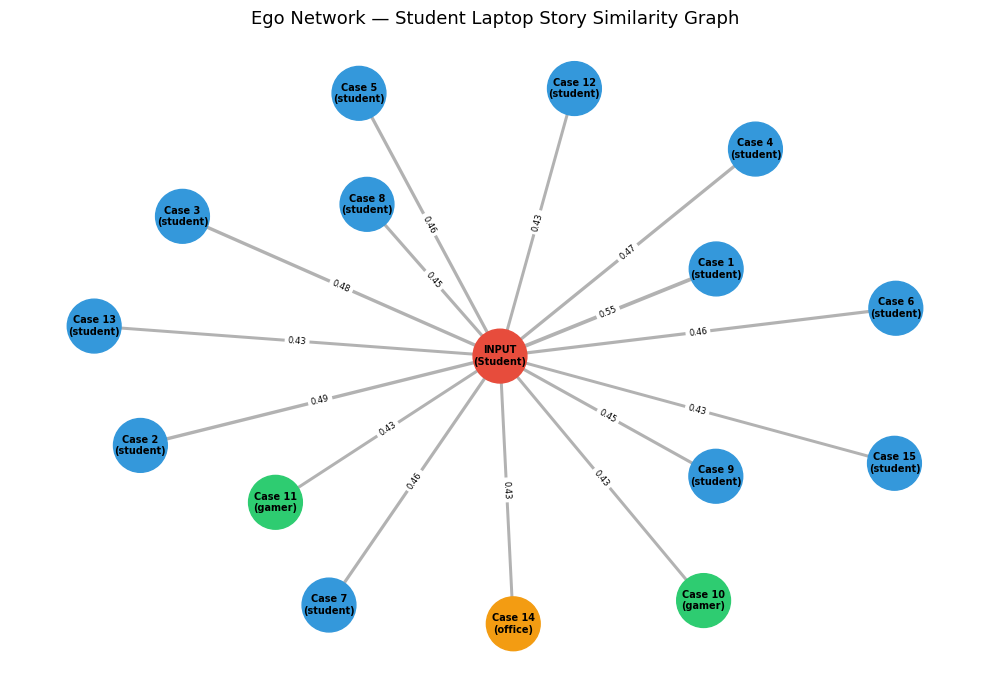

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# Step 5 — Build ego network
threshold = 0.3  # minimum similarity to draw an edge

G = nx.Graph()

# Add input story as center node
input_label = 'INPUT\n(Student)'
G.add_node(input_label, node_type='input')

# Add top 15 similar cases as surrounding nodes
for rank, (idx, score) in enumerate(zip(top_indices, top_scores)):
    if score >= threshold:
        profile = df.loc[idx, 'user_profile']
        node_label = f"Case {rank+1}\n({profile})"
        G.add_node(node_label, node_type=profile)
        G.add_edge(input_label, node_label, weight=round(score, 4))

print(f"Nodes: {G.number_of_nodes()}")
print(f"Edges: {G.number_of_edges()}")

# Step 6 — Visualize
plt.figure(figsize=(10, 7))

pos = nx.spring_layout(G, seed=42)

# Node colors
color_map = []
for node in G.nodes():
    ntype = G.nodes[node]['node_type']
    if ntype == 'input'      : color_map.append('#e74c3c')   # red = input
    elif ntype == 'student'  : color_map.append('#3498db')   # blue
    elif ntype == 'gamer'    : color_map.append('#2ecc71')   # green
    elif ntype == 'office'   : color_map.append('#f39c12')   # orange
    elif ntype == 'programmer': color_map.append('#9b59b6')  # purple
    else                     : color_map.append('#1abc9c')   # teal = designer

# Edge weights for thickness
edge_weights = [G[u][v]['weight'] * 5 for u, v in G.edges()]

nx.draw_networkx_nodes(G, pos, node_color=color_map, node_size=1500)
nx.draw_networkx_labels(G, pos, font_size=7, font_weight='bold')
nx.draw_networkx_edges(G, pos, width=edge_weights, alpha=0.6, edge_color='gray')
edge_labels = {(u,v): f"{G[u][v]['weight']:.2f}" for u,v in G.edges()}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=6)

plt.title('Ego Network — Student Laptop Story Similarity Graph', fontsize=13)
plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# Step 7 — Centrality Metrics
pagerank    = nx.pagerank(G, weight='weight')
degree_cen  = nx.degree_centrality(G)
between_cen = nx.betweenness_centrality(G, weight='weight')
closeness   = nx.closeness_centrality(G)

# Step 8 — Metrics Table
metrics_df = pd.DataFrame({
    'Node'                  : list(G.nodes()),
    'PageRank'              : [round(pagerank[n], 4)    for n in G.nodes()],
    'Degree Centrality'     : [round(degree_cen[n], 4)  for n in G.nodes()],
    'Betweenness Centrality': [round(between_cen[n], 4) for n in G.nodes()],
    'Closeness Centrality'  : [round(closeness[n], 4)   for n in G.nodes()],
})

metrics_df = metrics_df.sort_values('PageRank', ascending=False).reset_index(drop=True)
print(metrics_df.to_string(index=False))

              Node  PageRank  Degree Centrality  Betweenness Centrality  Closeness Centrality
  INPUT\n(Student)    0.4645             1.0000                     1.0                1.0000
 Case 1\n(student)    0.0409             0.0667                     0.0                0.5172
 Case 2\n(student)    0.0374             0.0667                     0.0                0.5172
 Case 3\n(student)    0.0372             0.0667                     0.0                0.5172
 Case 4\n(student)    0.0364             0.0667                     0.0                0.5172
 Case 5\n(student)    0.0361             0.0667                     0.0                0.5172
 Case 6\n(student)    0.0357             0.0667                     0.0                0.5172
 Case 7\n(student)    0.0356             0.0667                     0.0                0.5172
 Case 8\n(student)    0.0354             0.0667                     0.0                0.5172
 Case 9\n(student)    0.0352             0.0667             

Why Python and NetworkX Are Suitable Tools for This Task
Python is a natural choice for this task because it brings together all the components needed in one environment — text processing, machine learning, and graph analysis — without switching between tools. The entire pipeline, from TF-IDF vectorization to cosine similarity computation to graph construction, was written and executed in a single notebook.
NetworkX is specifically designed for building, manipulating, and analyzing graphs in Python. It made it straightforward to construct the ego network by adding nodes and weighted edges directly from the similarity scores, and it provided all four centrality metrics — PageRank, Degree Centrality, Betweenness Centrality, and Closeness Centrality — as built-in functions with no additional implementation required.
Together, Python and NetworkX allowed the entire workflow to be transparent and reproducible. Every step from entering the input story to producing the final metrics table can be traced, modified, and re-run, which makes them well-suited for exploratory data analysis tasks like this one where the process matters as much as the result.



What the Graph Shows
The ego network visualizes how the input student laptop story relates to the 15 most similar cases in the dataset. The input story sits at the center as the ego node, connected to all surrounding cases by edges whose thickness reflects the strength of similarity.
The graph shows that the input story is most strongly connected to other student profiles, which confirms that the clustering from Task 1 was meaningful — student reviews share enough vocabulary and context to be clearly distinguishable from other profiles. Two gamer cases (Case 10 and Case 11) and one office case (Case 14) also appear in the network, suggesting that some reviews cross profile boundaries in their language, likely because they share common complaints about hardware limitations such as storage and integrated graphics.
From the centrality metrics, four roles emerge:

Most representative case — Case 1 (student): This case has the highest PageRank, meaning it received the most influence through weighted connections. It is the single most similar story to the input and best represents the typical student laptop experience in the dataset.
Most connected case — INPUT (Student): The input node has the highest Degree Centrality (1.0) as it is directly connected to every other node in the network. This is expected in an ego network where the center node defines the structure.
Bridge case — INPUT (Student): The input node also holds the highest Betweenness Centrality (1.0) because all paths between any two nodes must pass through it. No two surrounding cases are directly connected to each other, making the input the sole bridge in this network.
Unusual cases — Case 10 and Case 11 (gamer): These are the only non-student profiles with low PageRank scores. Their presence in the network suggests they share surface-level vocabulary with the student input story — likely around storage complaints and integrated graphics — but they do not truly belong to the same user profile cluster.
